# Step 6 — Visualization + Ground-Truth Evaluation Metrics (Upgraded) ✅

| | |
|---|---|
| **Input** | `output/step_5/ttc_{lidar,radar,camera,fused}.csv`, nuScenes `sample_annotation` (ground truth) |
| **Outputs** | `output/step_6/trend_<object>.png` — per-object speed/TTC trend plots |
| | `output/step_6/evaluation_metrics.csv` — the full comparison table (this was missing) |
| | `output/step_6/evaluation_charts.png` |

---

### Part A — your original visualization, fixed
- Updated to read the upgraded Step 5 output (`ttc_fused.csv`), computing `speed_capped`/`ttc_capped` inline for display.
- Figures now save to disk automatically (needed for your README/portfolio — `plt.show()` alone doesn't persist anything).
- Removed the duplicate filter line and the fragile `ax2.patches[0]` legend hack.

### Part B — NEW: the missing evaluation metrics
No notebook you've shared computes MAE, RMSE, Percent_Valid, Stability, or Good/Bad% — the numbers in your dissertation's Table (section 3.6.4) don't have a traceable source in the code reviewed so far. This section builds them from **real nuScenes ground truth**:

1. Every `sample_annotation` has an `instance_token` — a consistent ID for the same real-world object across every frame it appears in, and a `translation` already in the global frame (matching your pipeline).
2. True TTC is computed for each ground-truth instance the same way as your predicted TTC — same `compute_ttc()` logic, same ego-relative frame, from real position differences over real time.
3. Each of your predicted tracks (LiDAR/Radar/Camera/Fused) is matched to its nearest ground-truth instance per frame (within a distance gate), giving genuine (predicted, ground-truth) TTC pairs to compute error metrics from.

In [1]:
# CELL 1 — Verify config.py exists, load Step 5 outputs

from pathlib import Path

if not Path("config.py").exists():
    raise FileNotFoundError("config.py not found. Copy it from the repo root.")

from config import DATA_ROOT, NUSCENES_VERSION, STEP0_DIR, STEP1_DIR, STEP5_DIR, OUTPUT_ROOT

STEP6_DIR = OUTPUT_ROOT / "step_6"
STEP6_DIR.mkdir(parents=True, exist_ok=True)

for name in ["lidar", "radar", "camera", "camera_mono", "fused"]:
    p = STEP5_DIR / f"ttc_{name}.csv"
    if not p.exists():
        raise FileNotFoundError(f"{p} not found — run Step 5 first.")

print("config OK. All Step 5 outputs found.")
print(f"STEP6_DIR: {STEP6_DIR}")

config.py loaded. PROJECT_ROOT = F:\Sensor fusion Research
DATA_ROOT   = F:\Sensor fusion Research\DATA SET\archive
OUTPUT_ROOT = F:\Sensor fusion Research\output
config OK. All Step 5 outputs found.
STEP6_DIR: F:\Sensor fusion Research\output\step_6


## Part A — Trend visualization (your original, fixed)

Plotting 80 objects with 3+ points in sample_0001..sample_0010


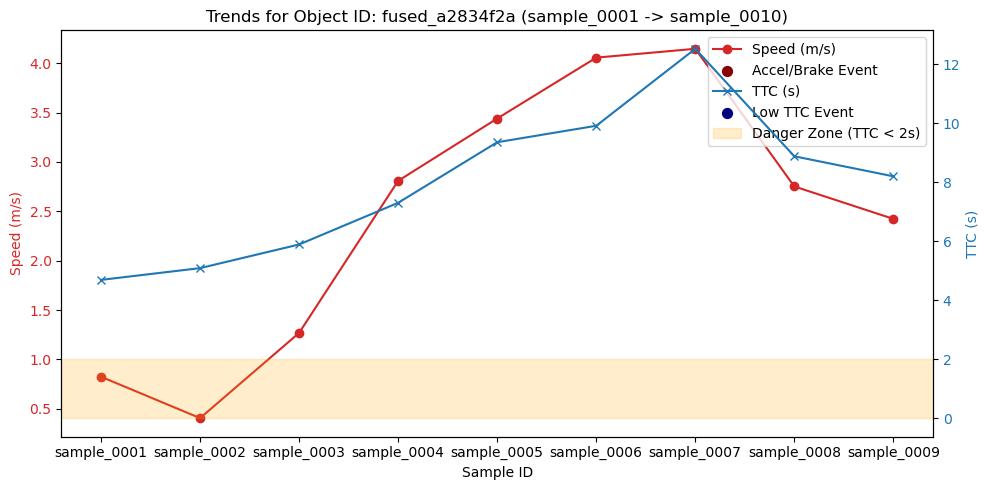

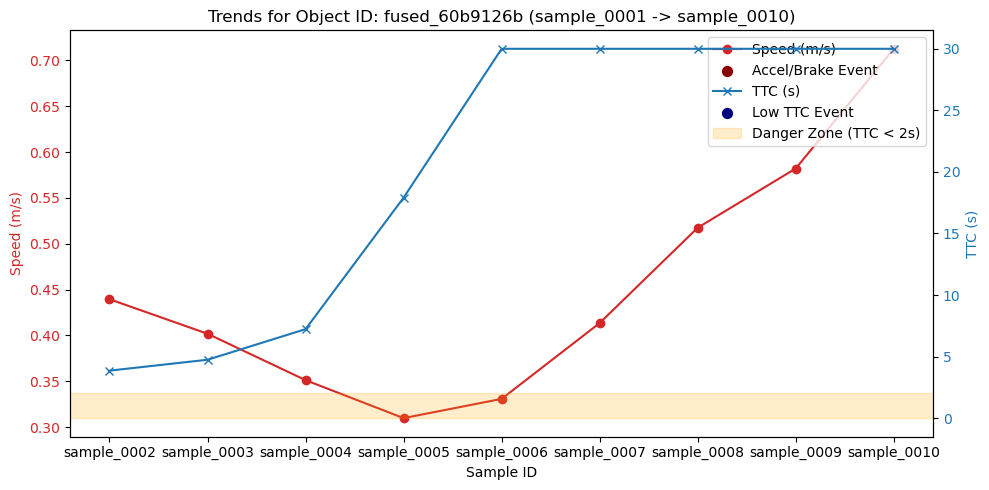

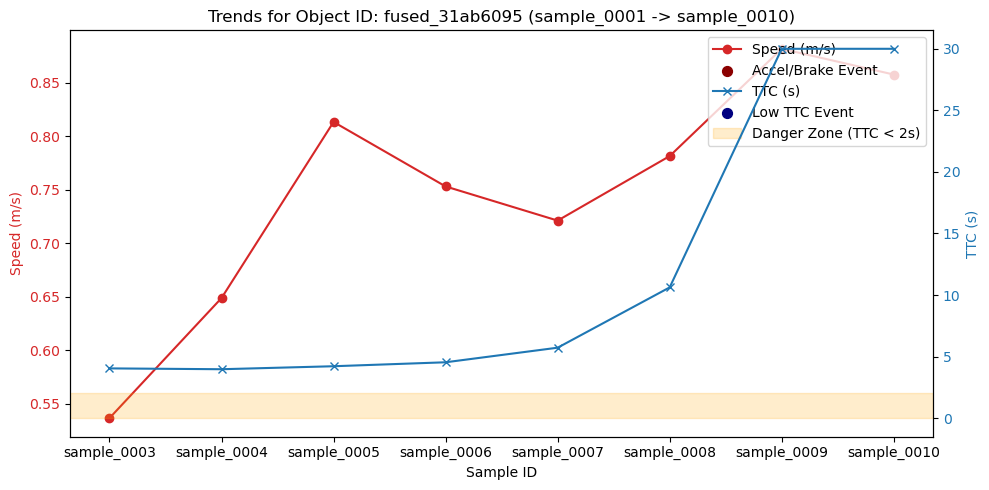

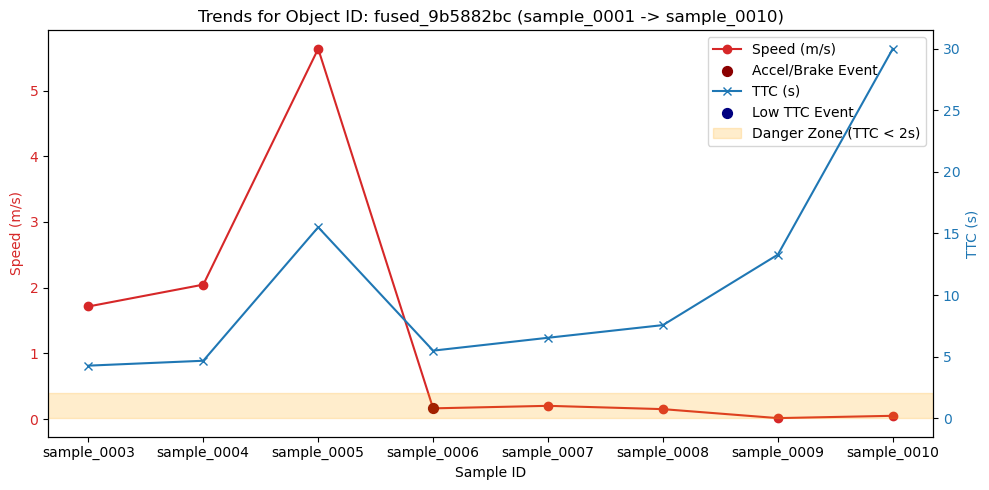

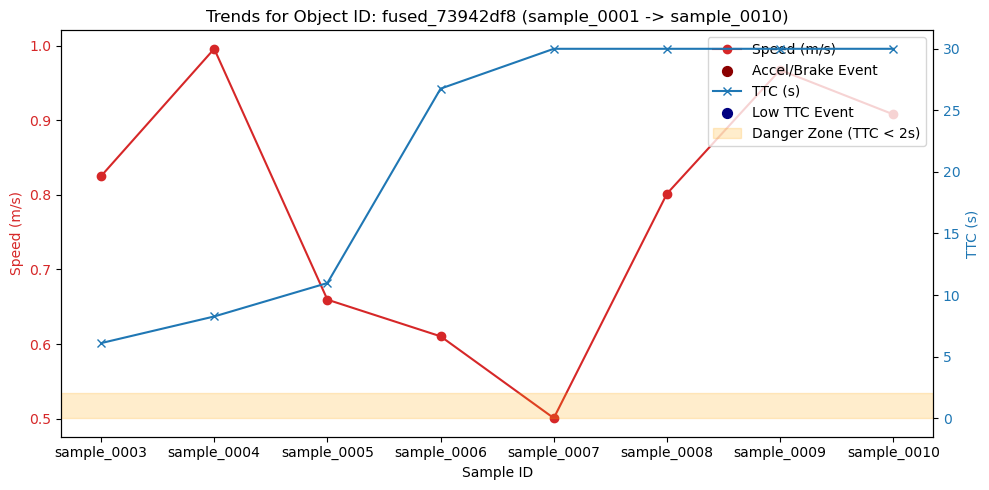

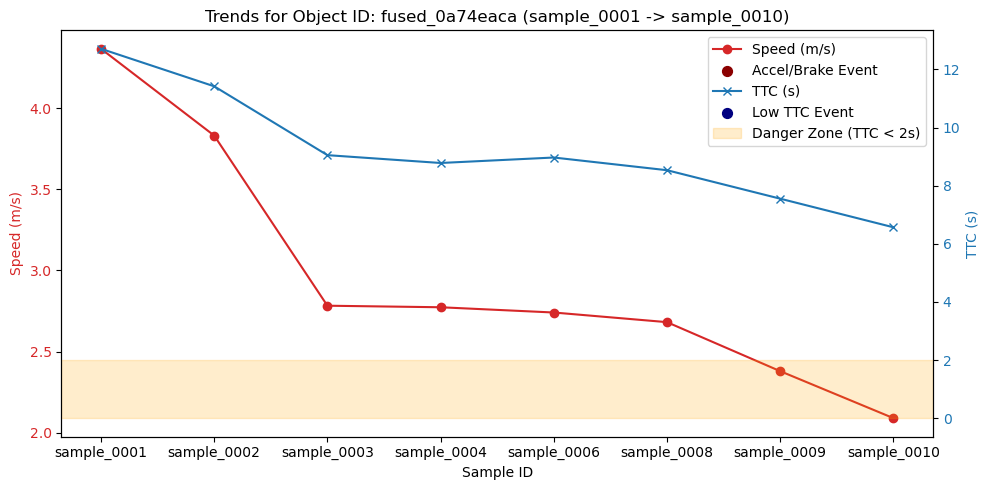

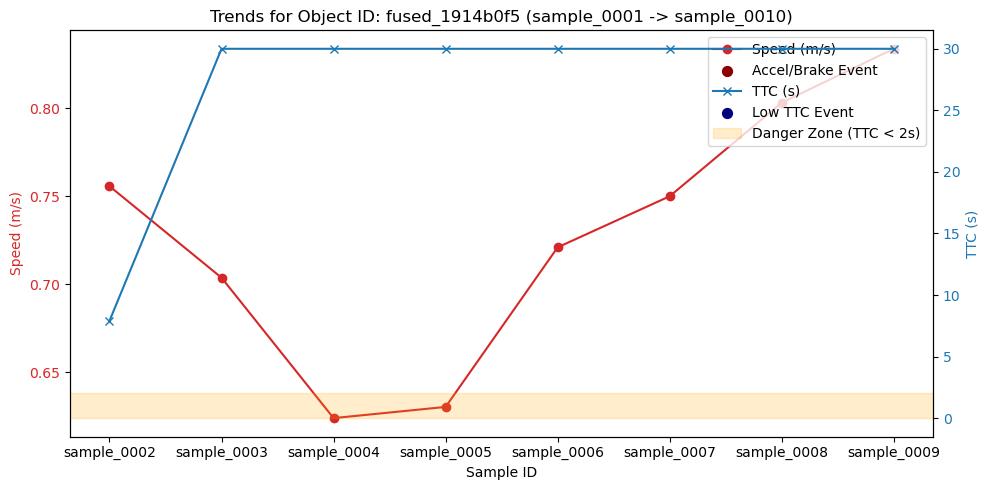

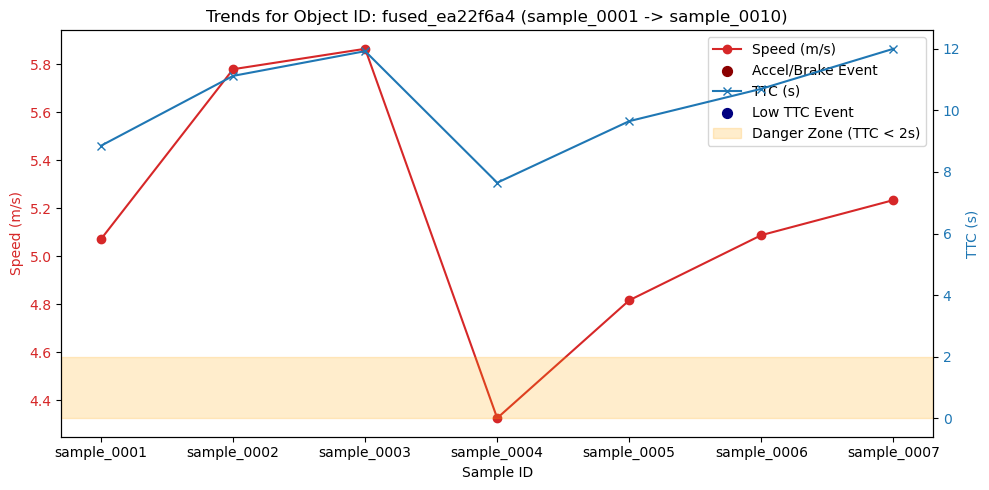

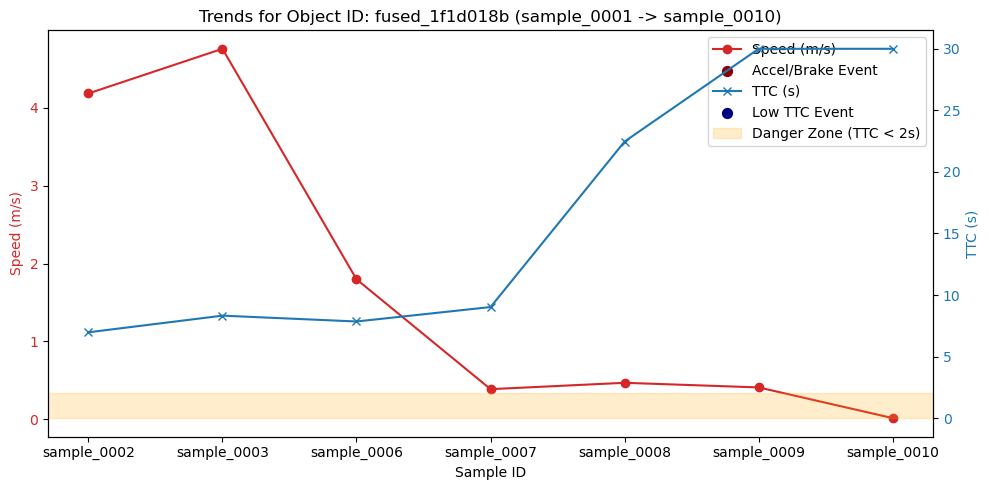

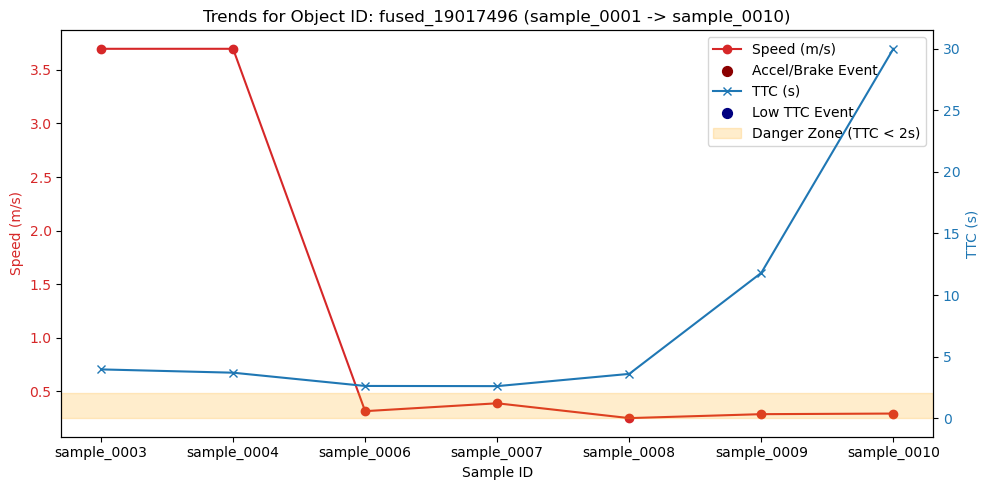

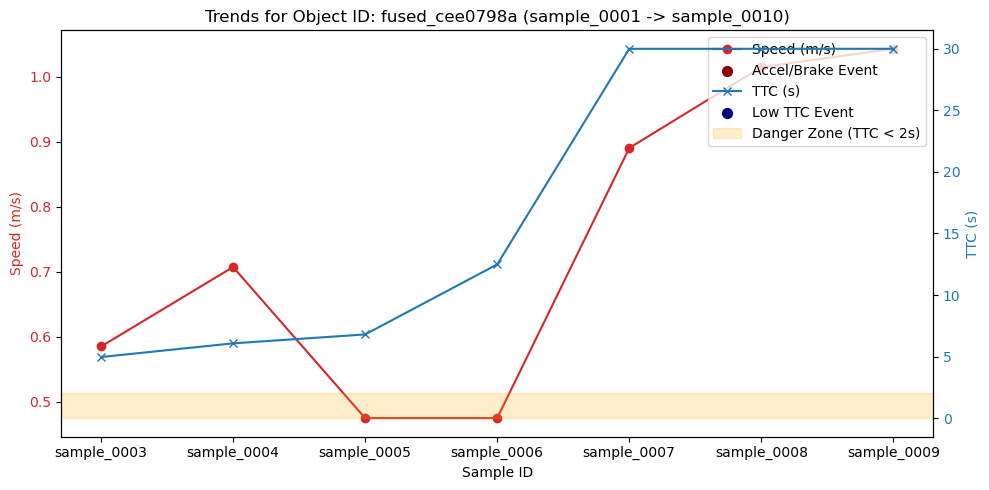

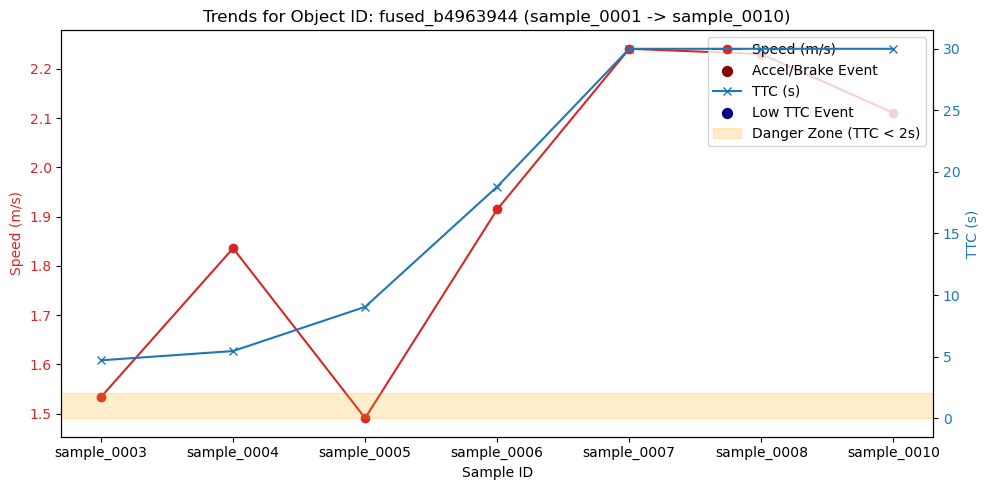

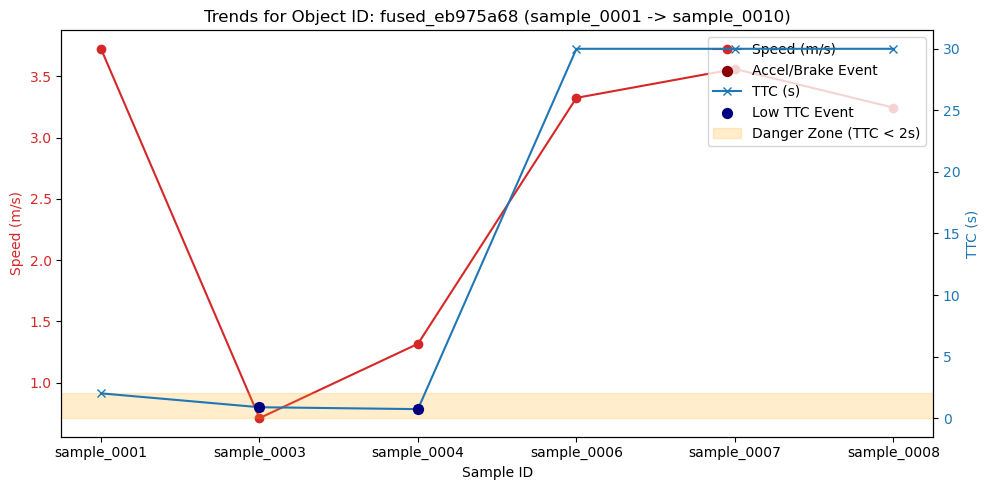

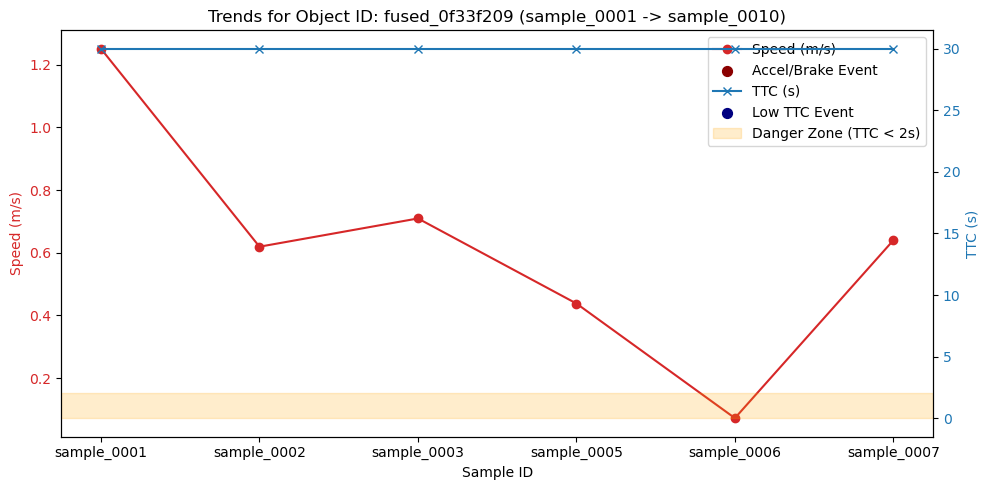

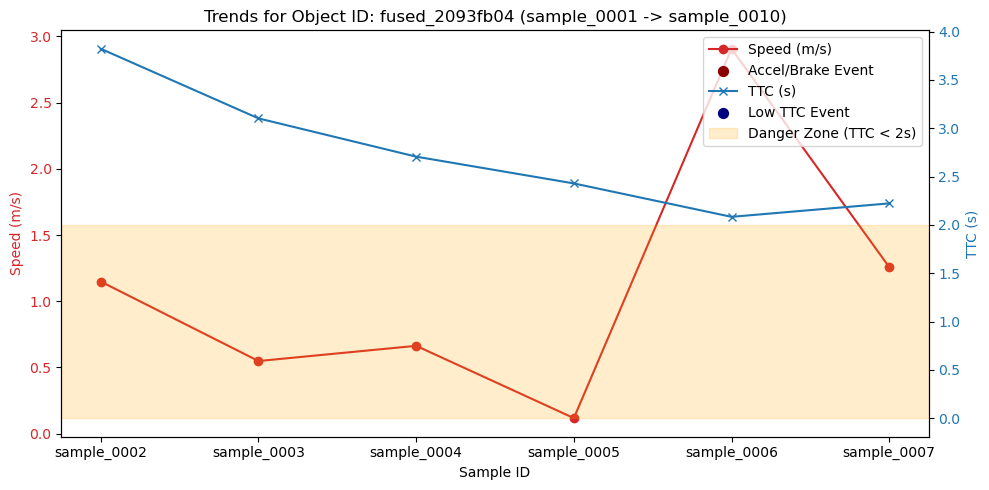

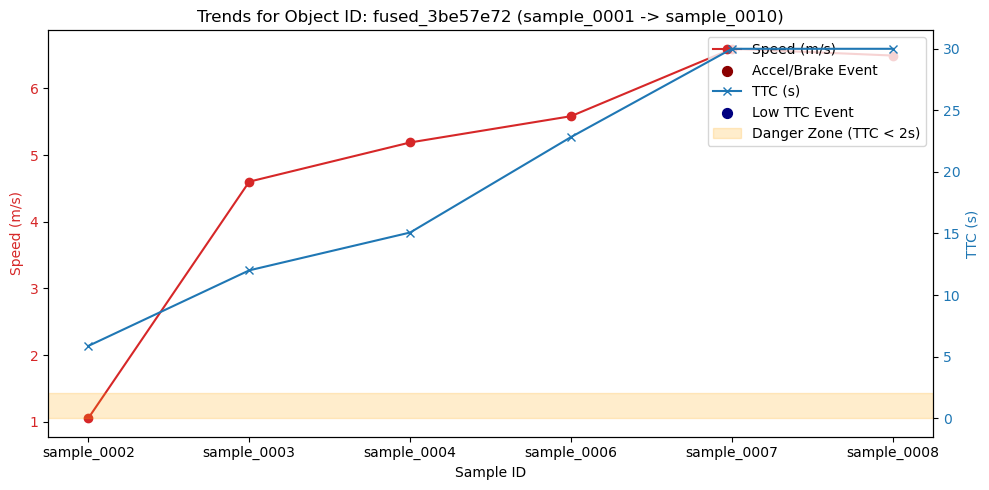

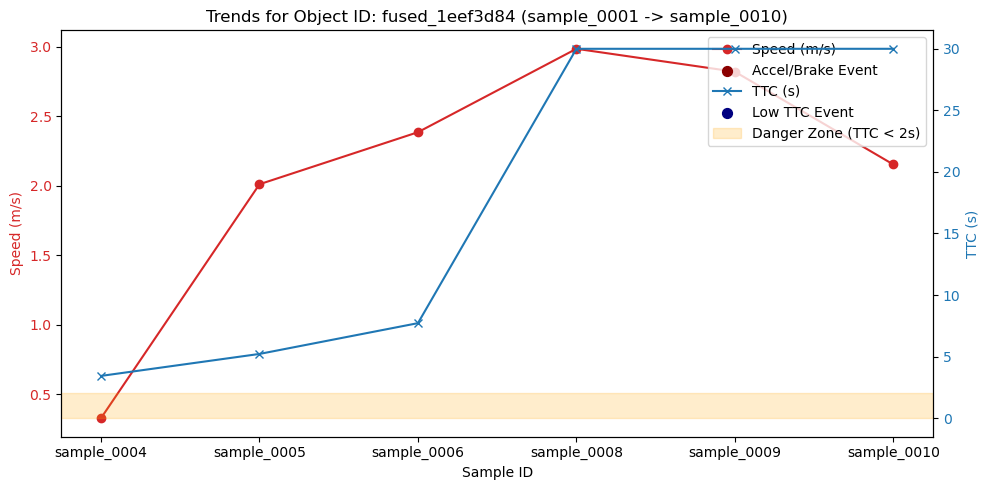

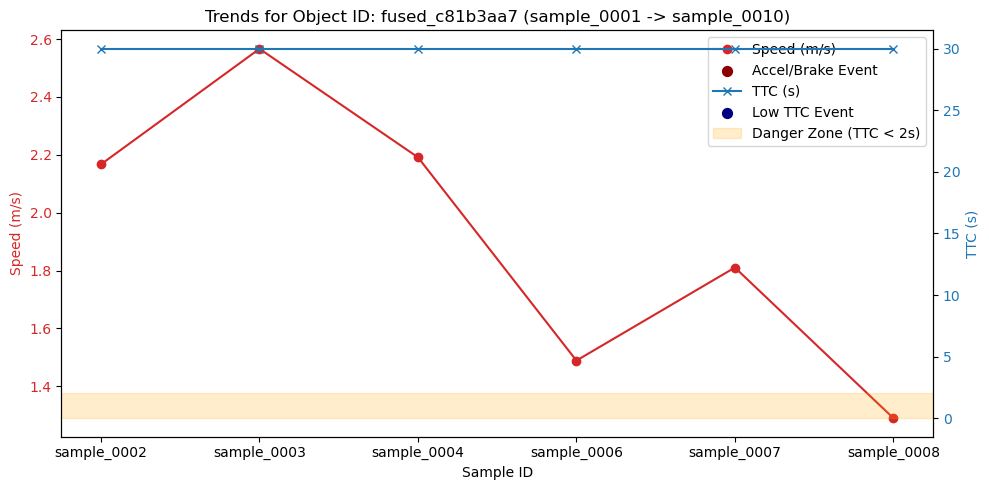

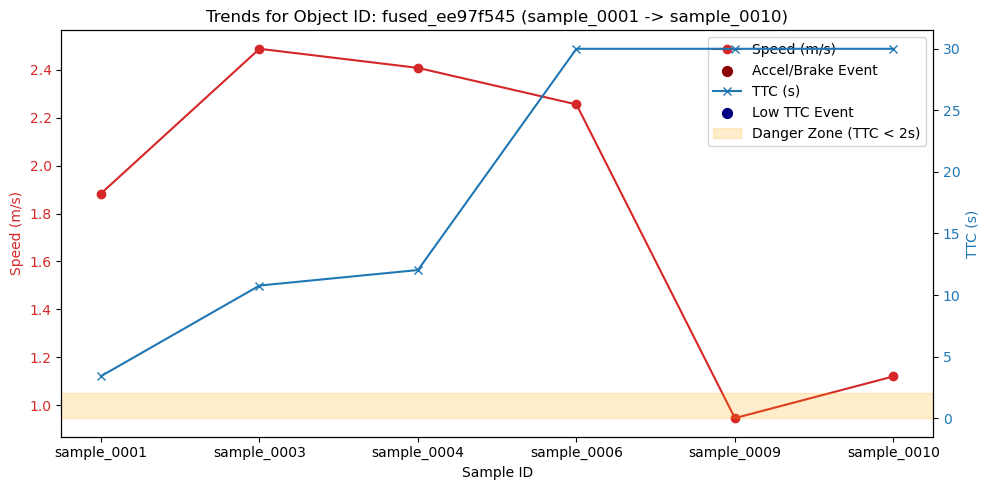

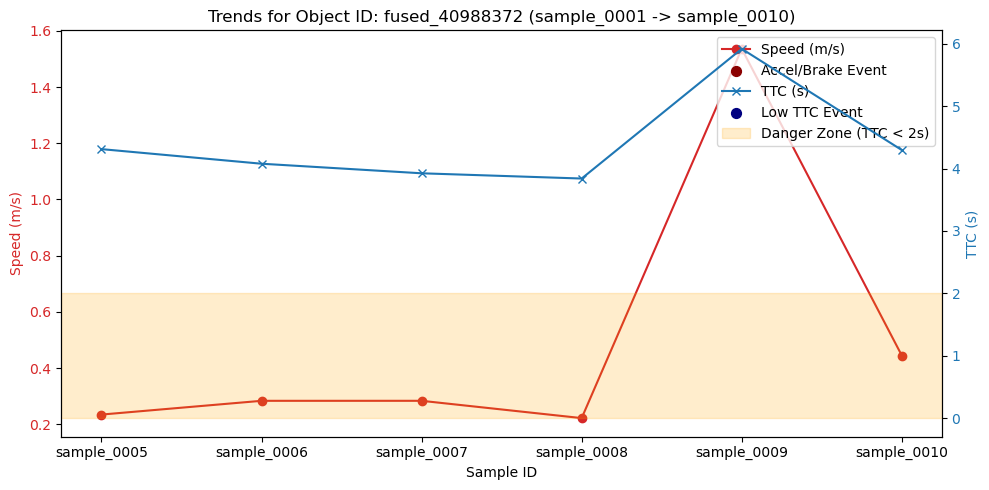

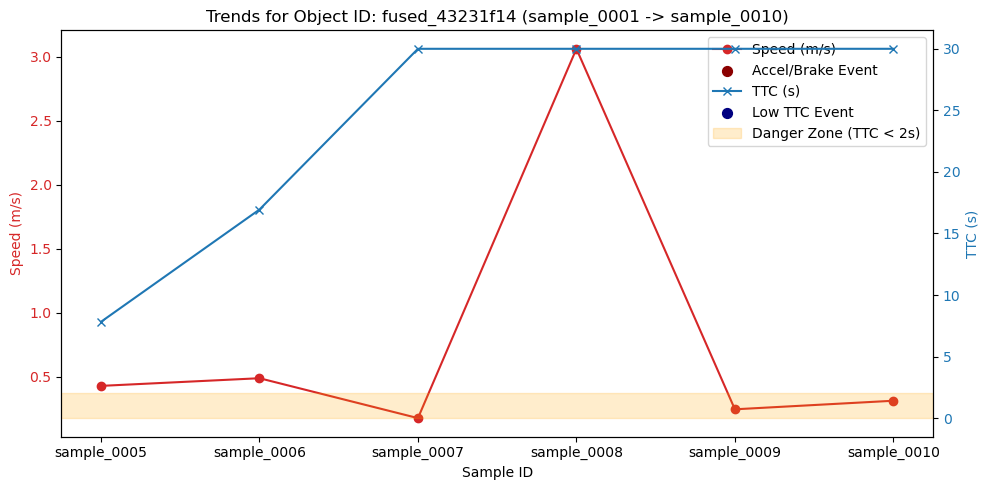

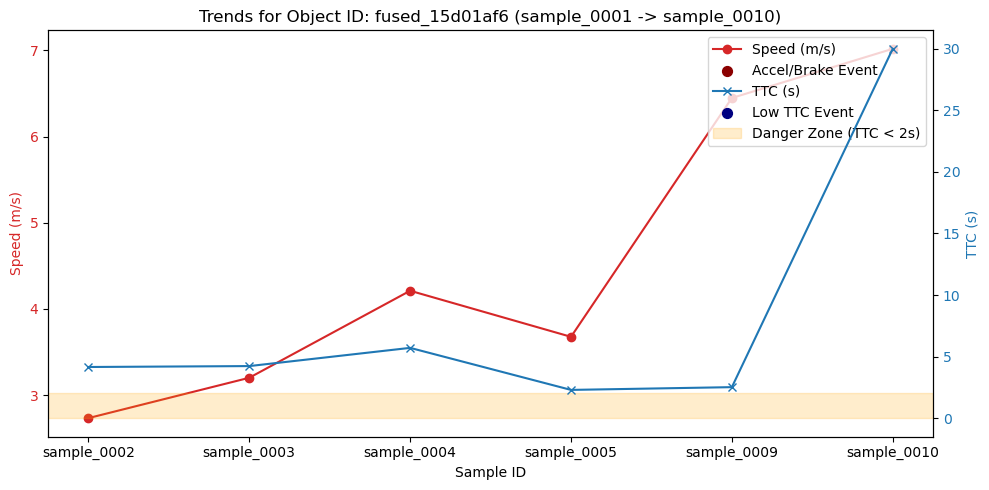

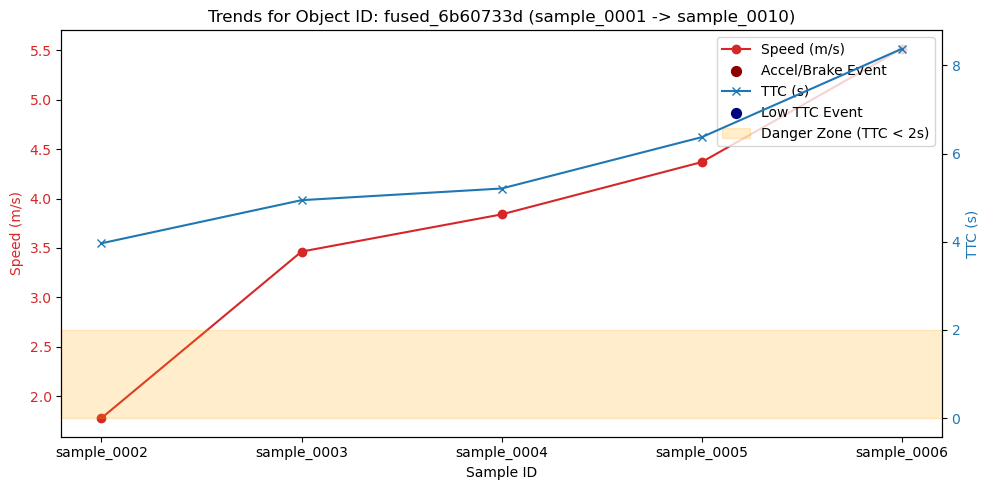

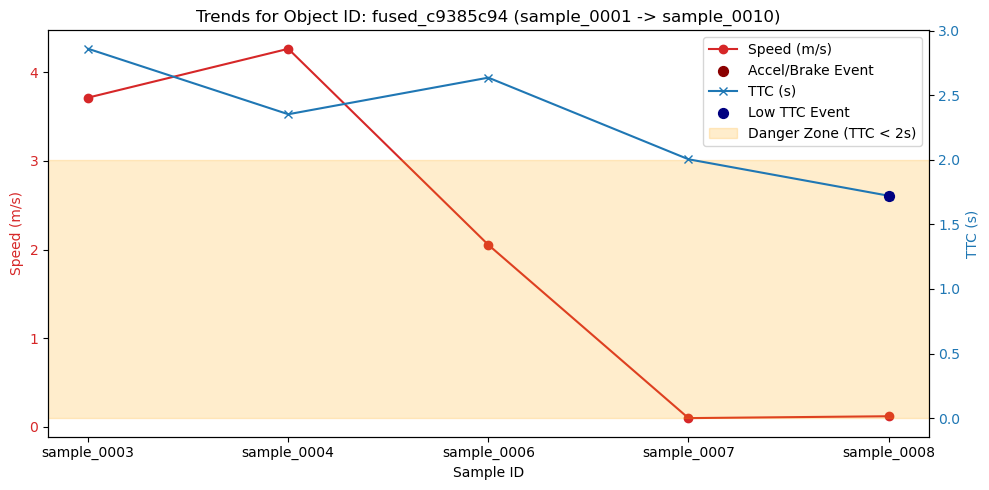

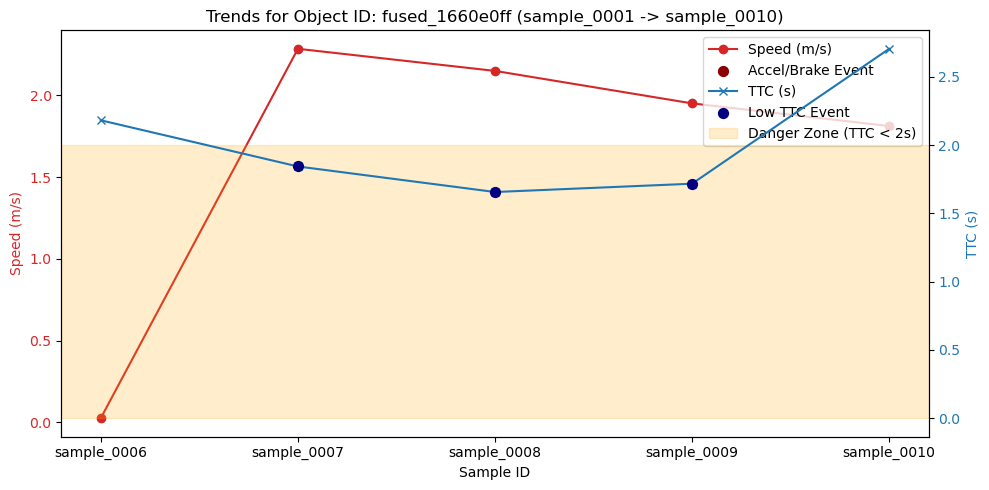

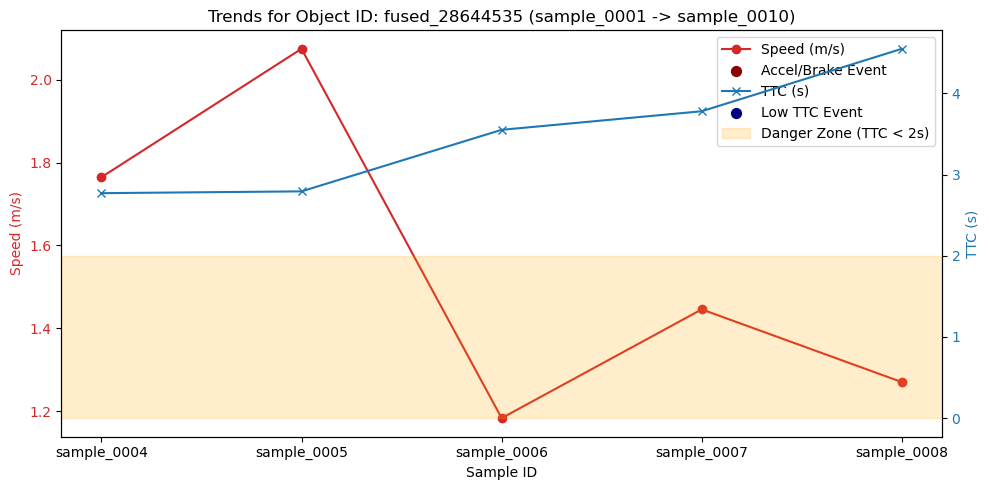

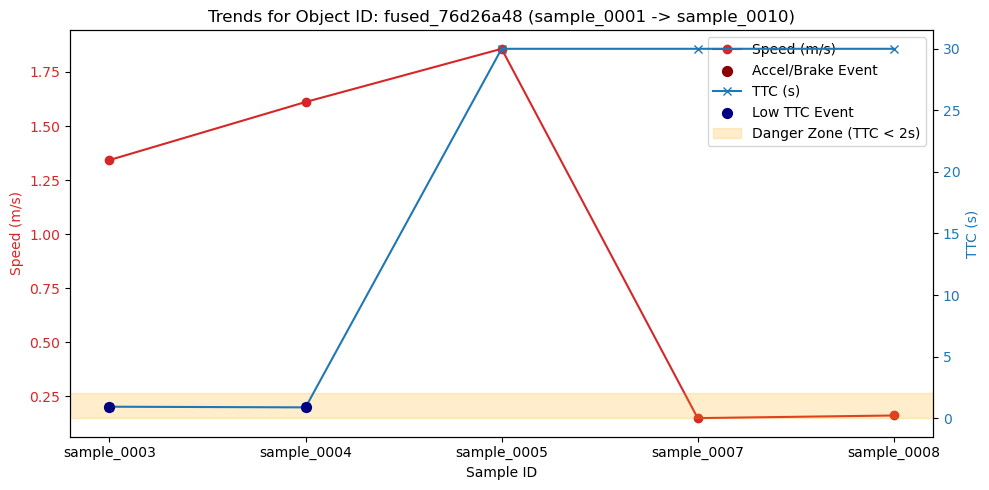

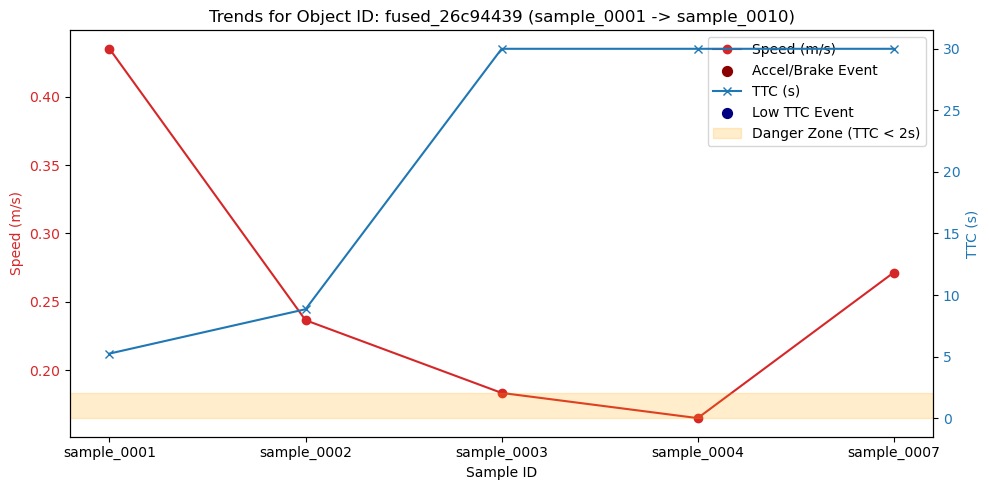

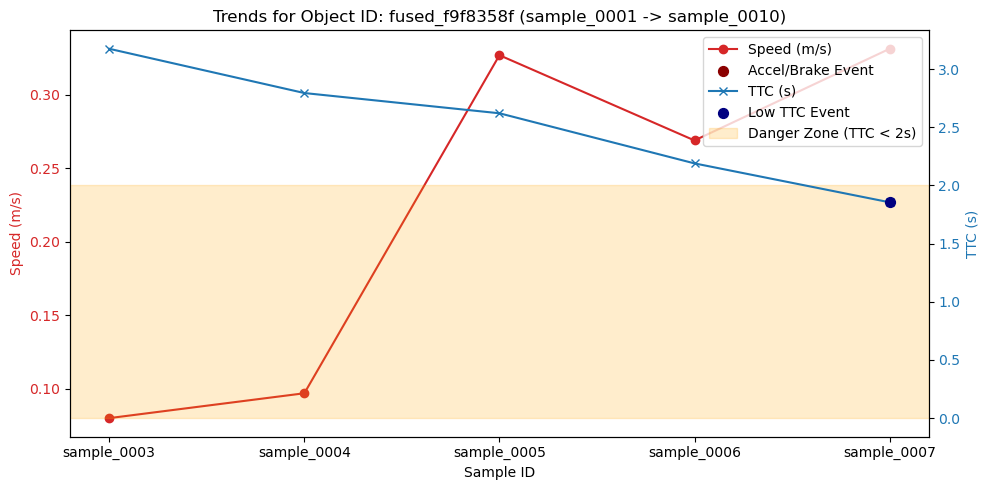

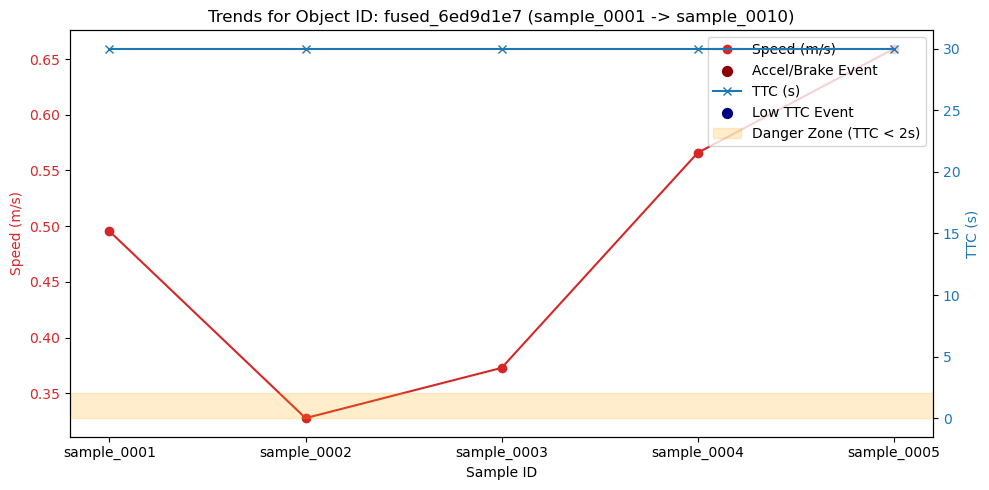

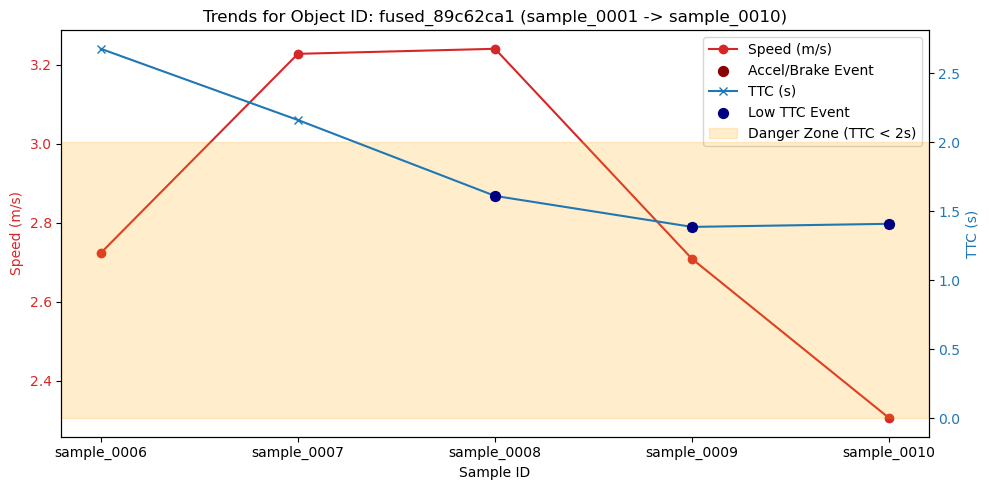

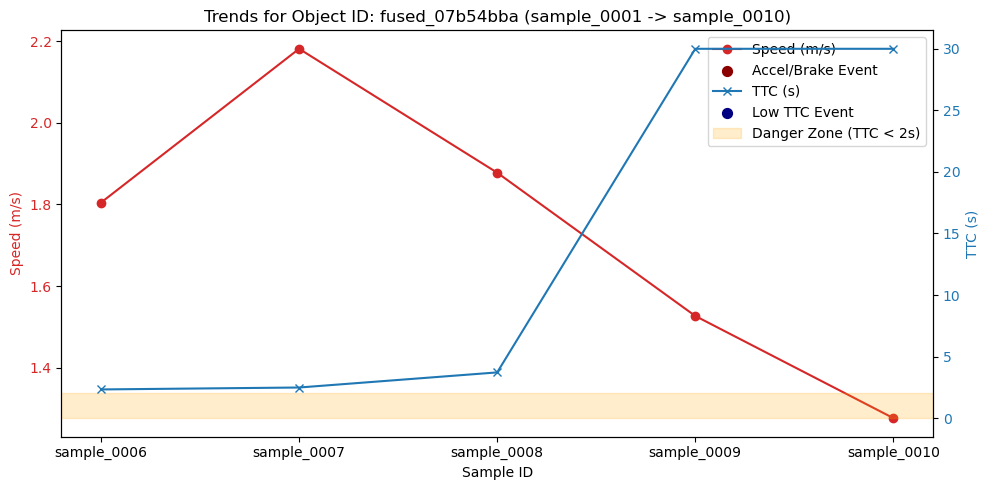

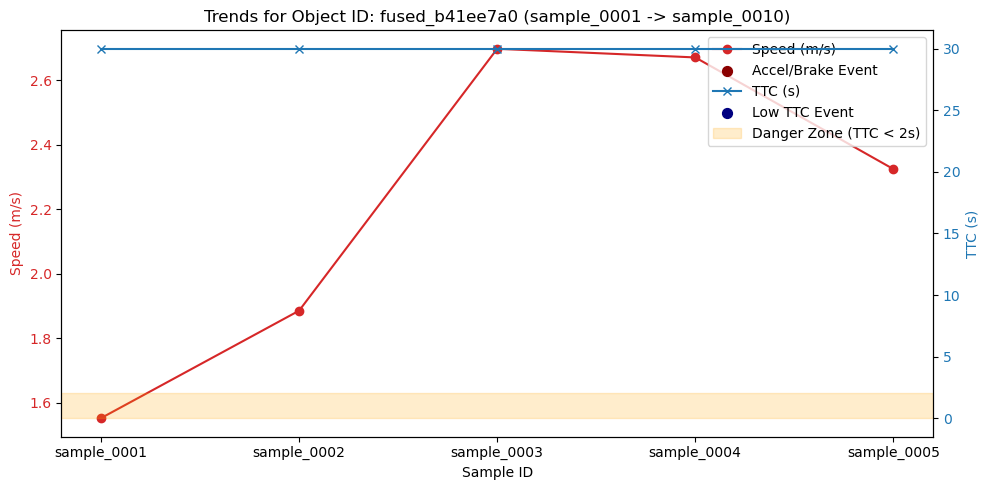

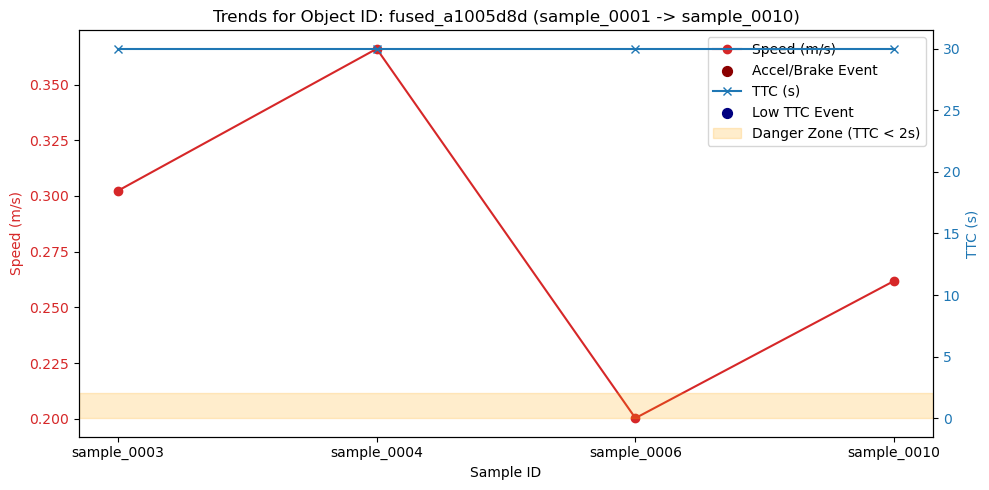

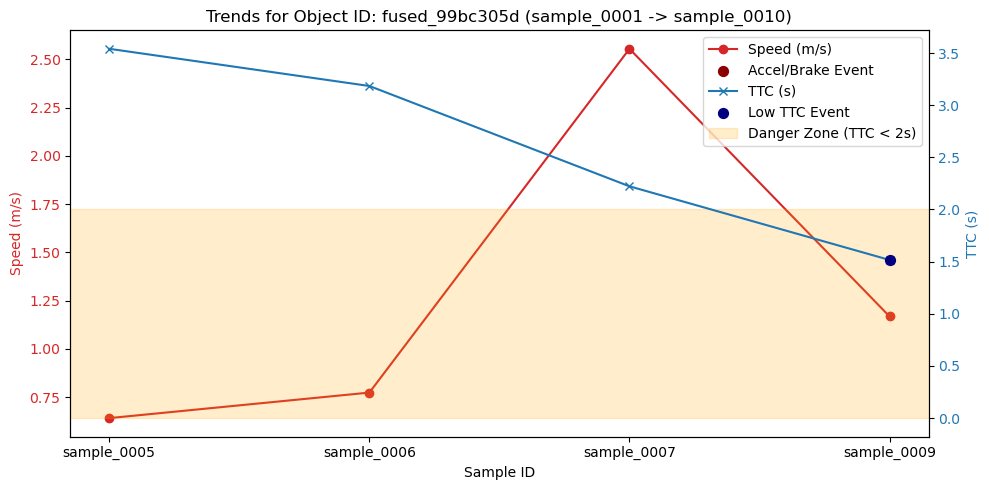

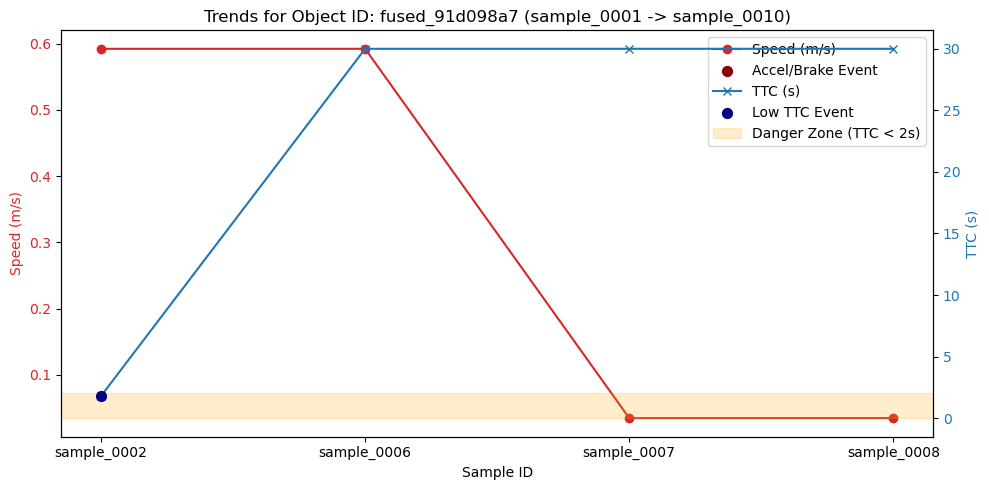

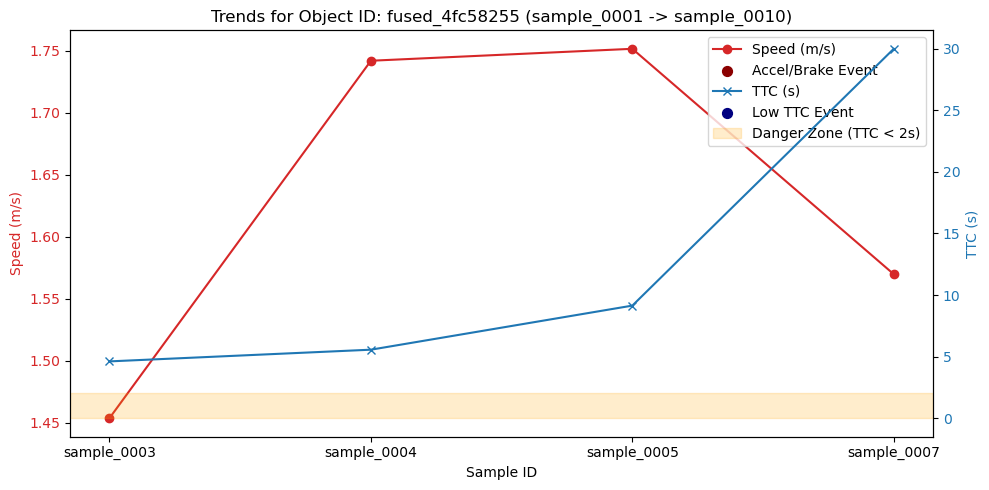

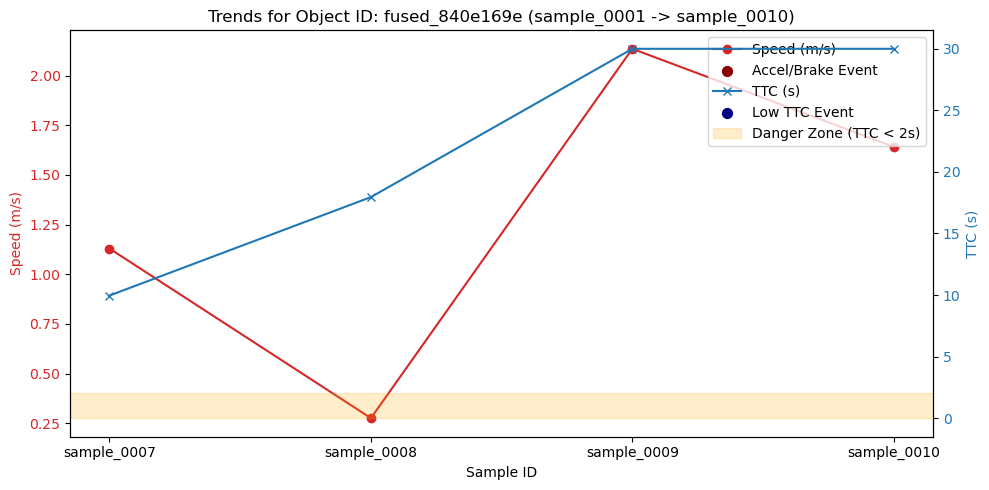

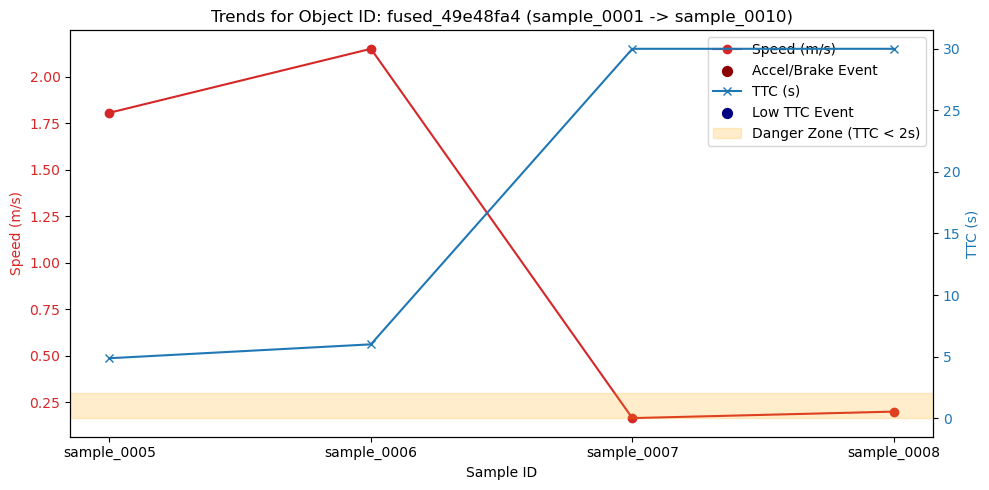

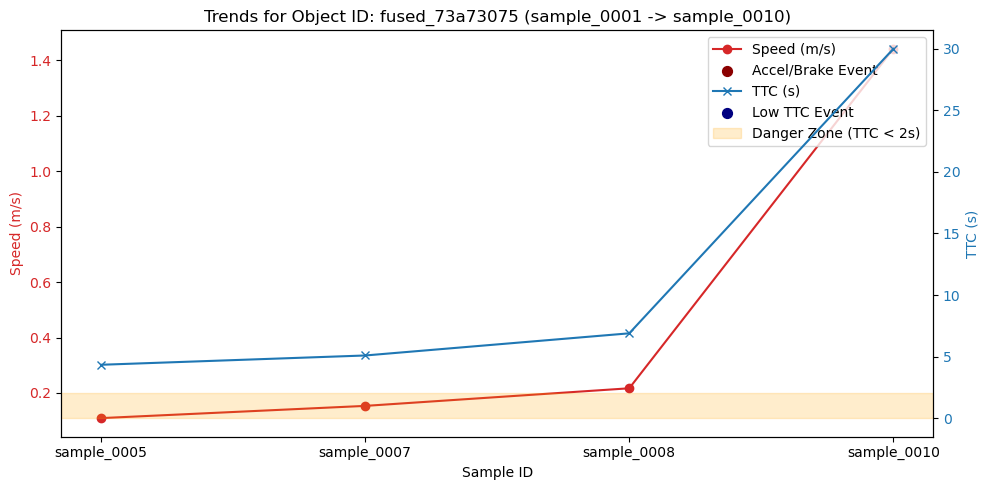

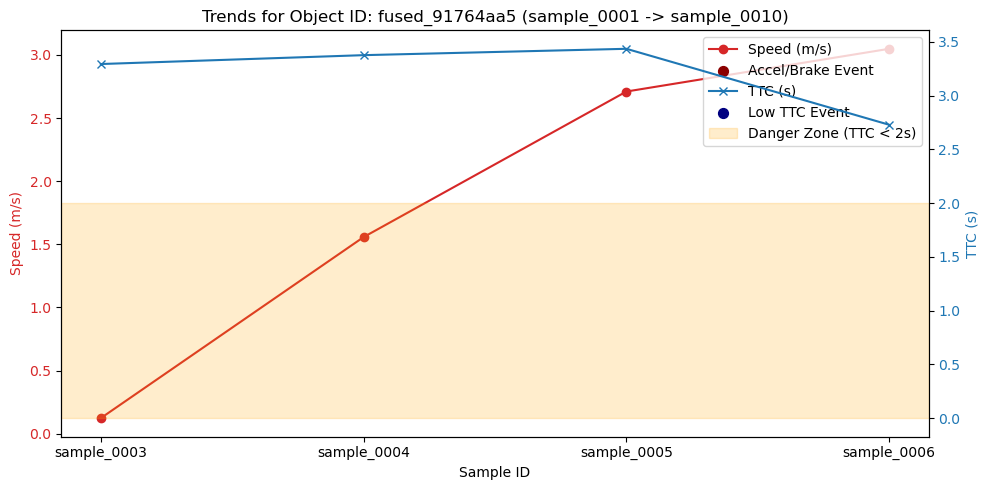

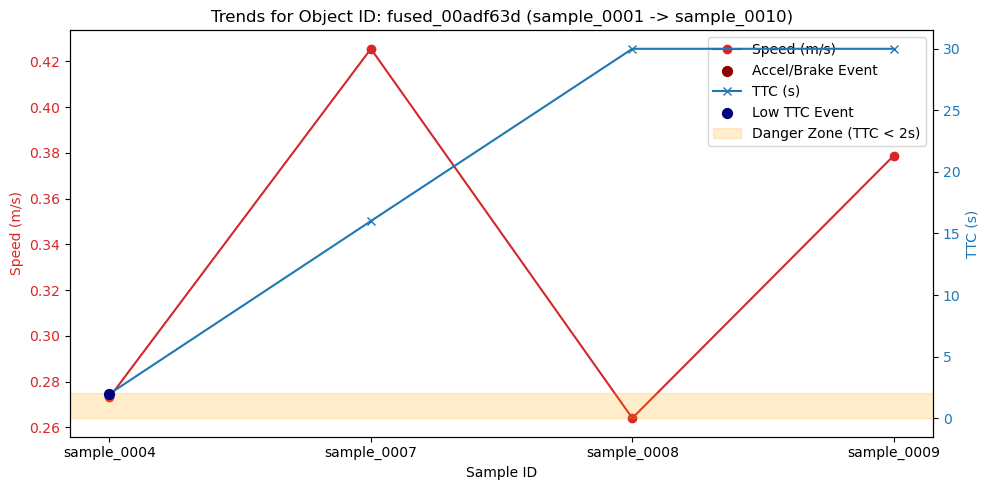

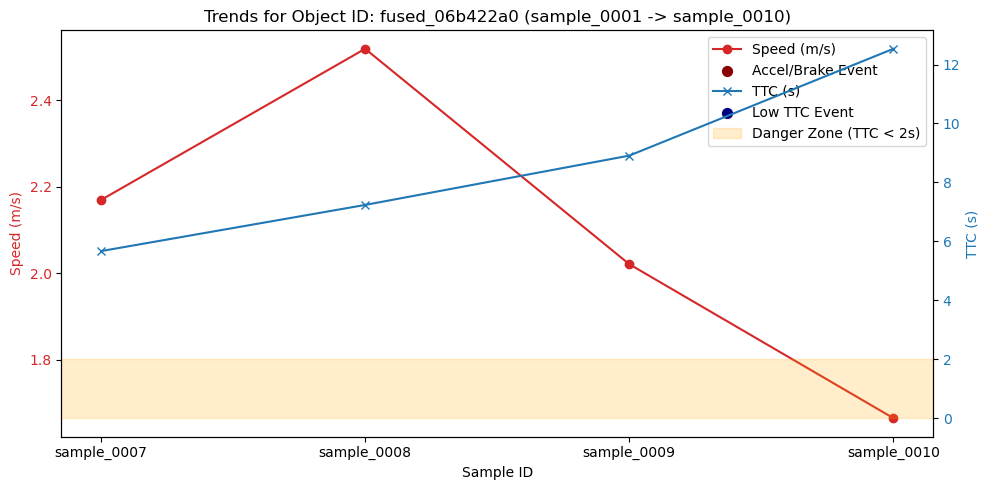

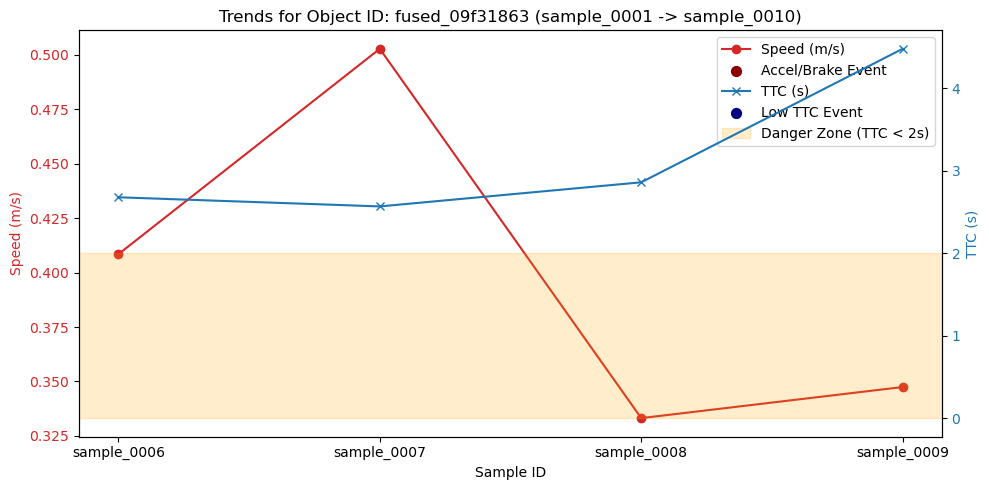

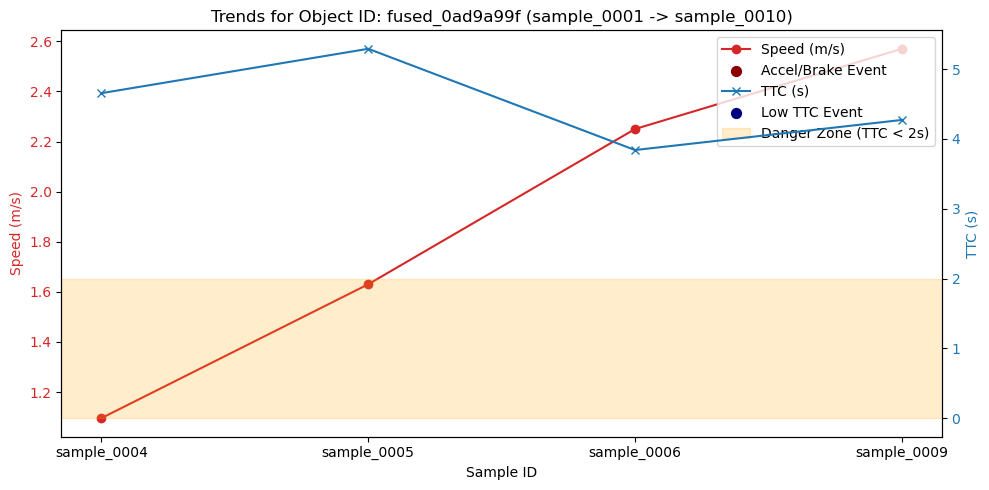

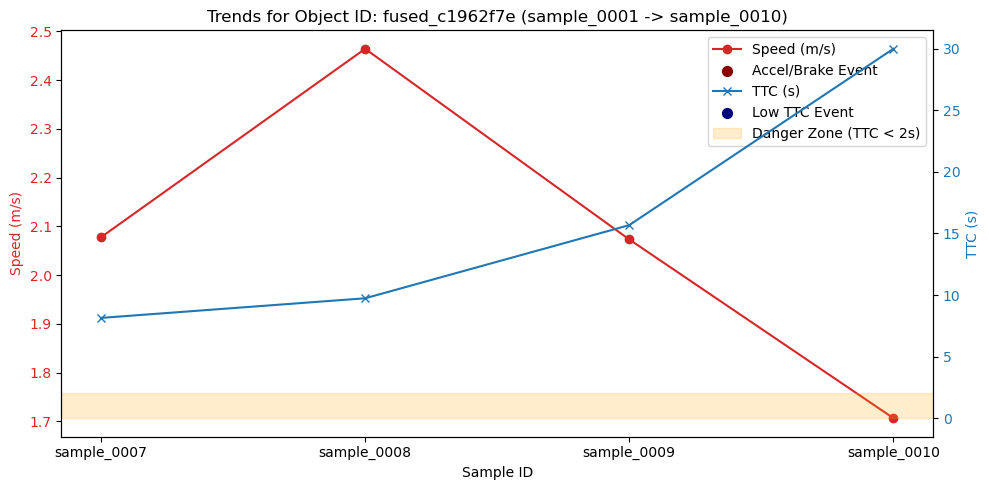

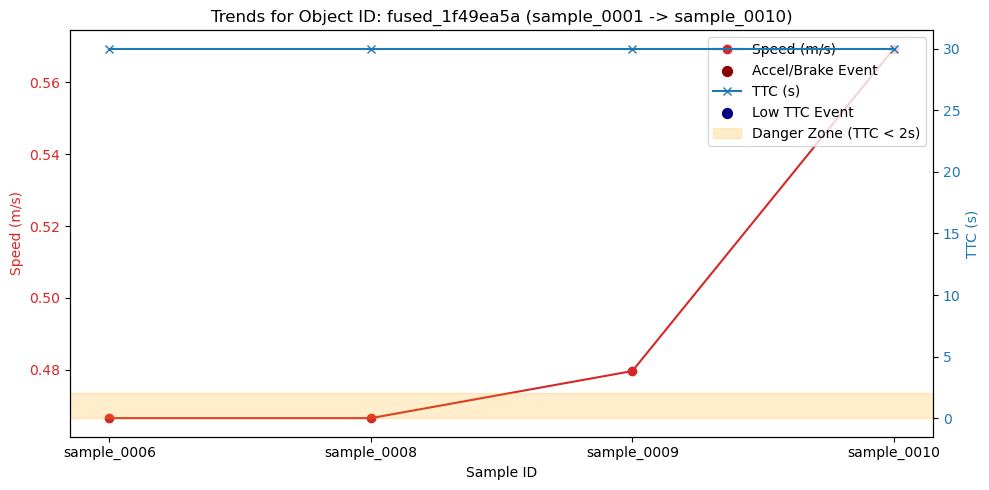

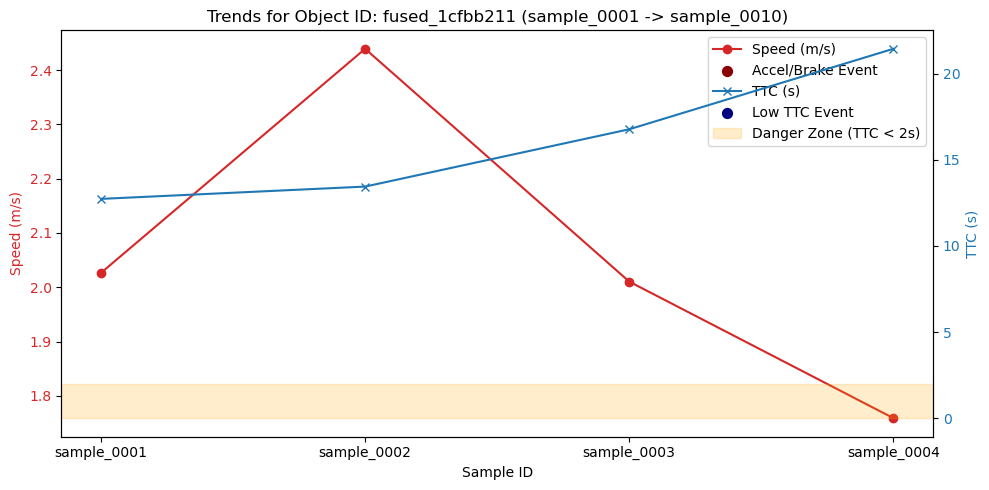

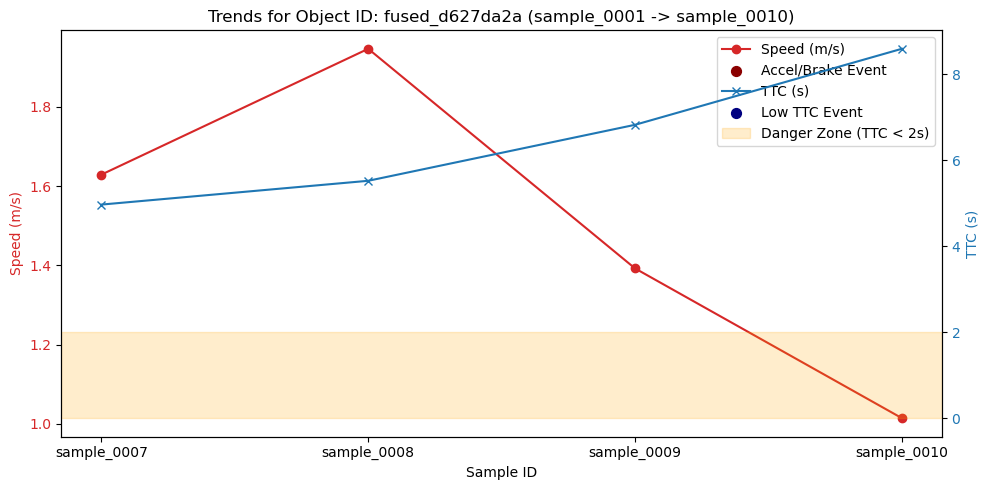

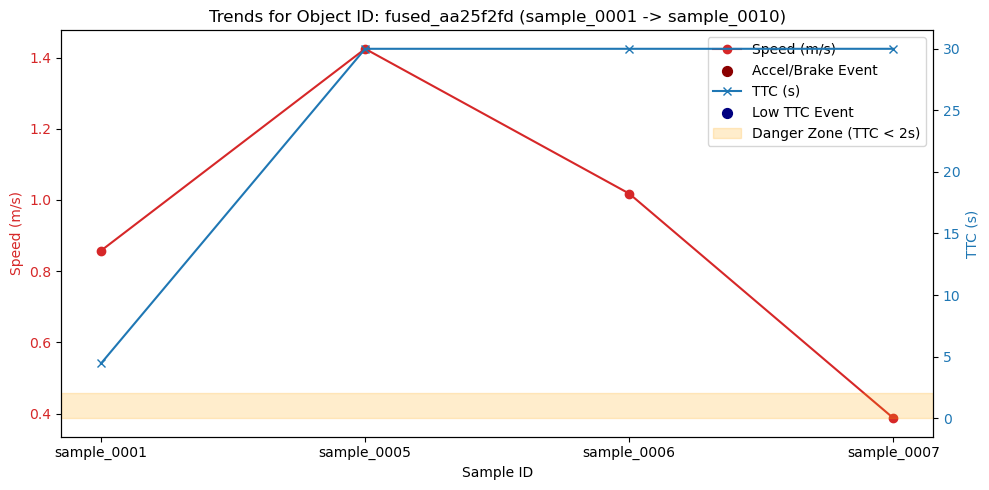

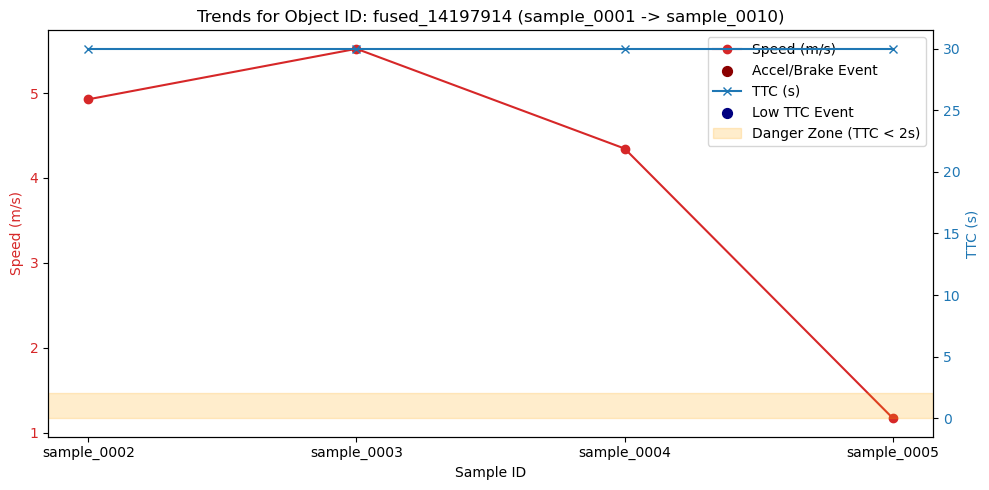

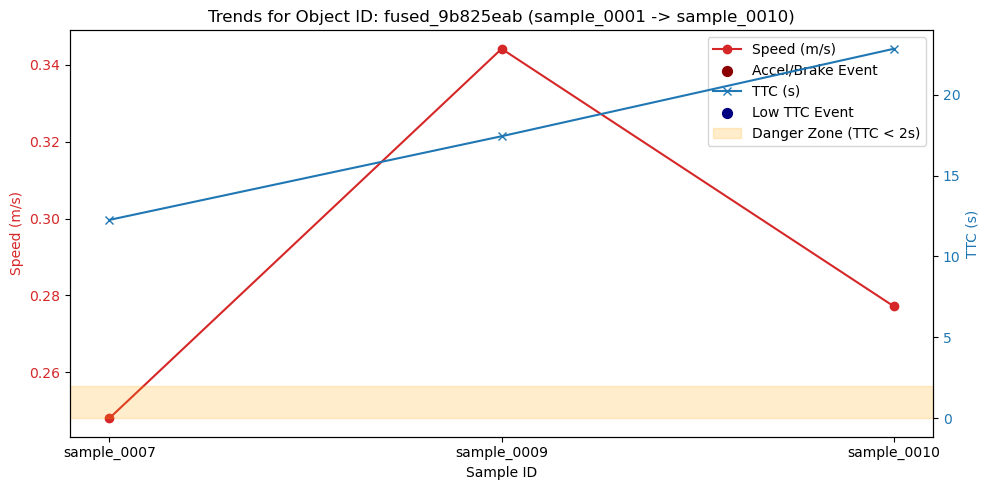

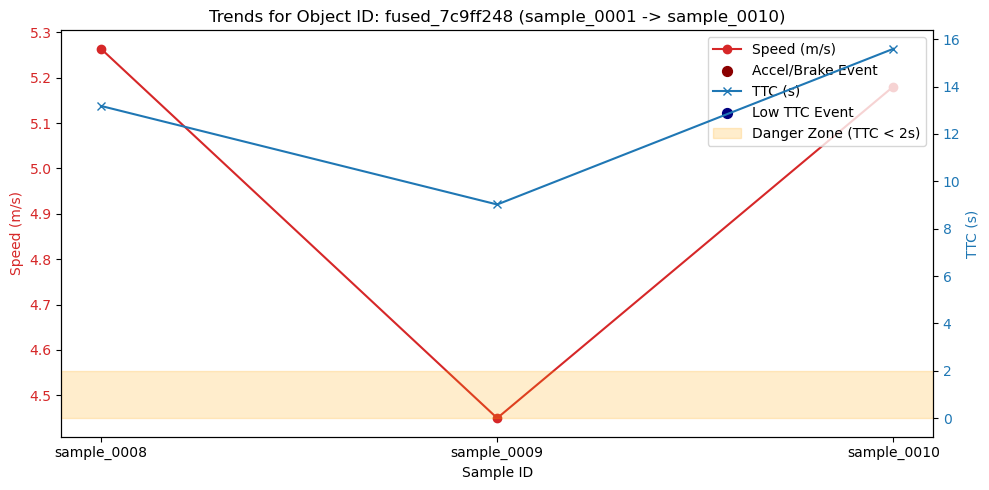

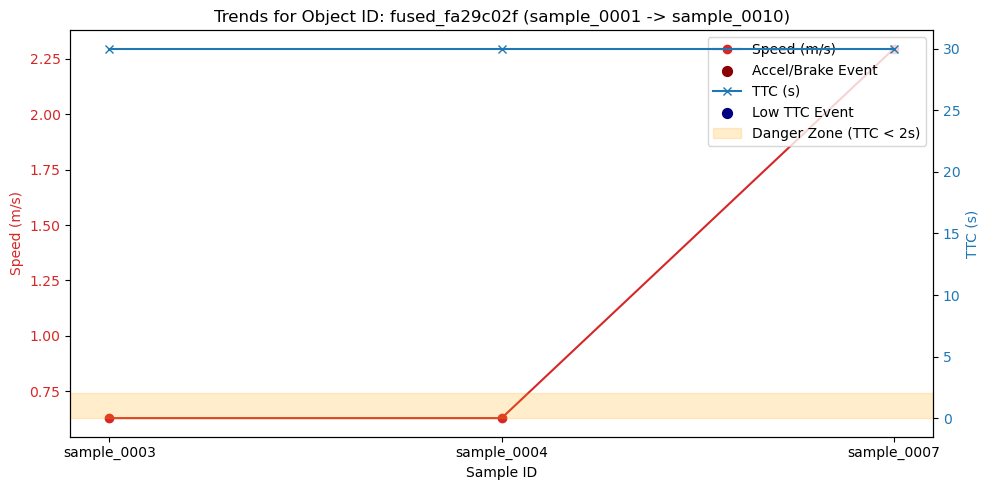

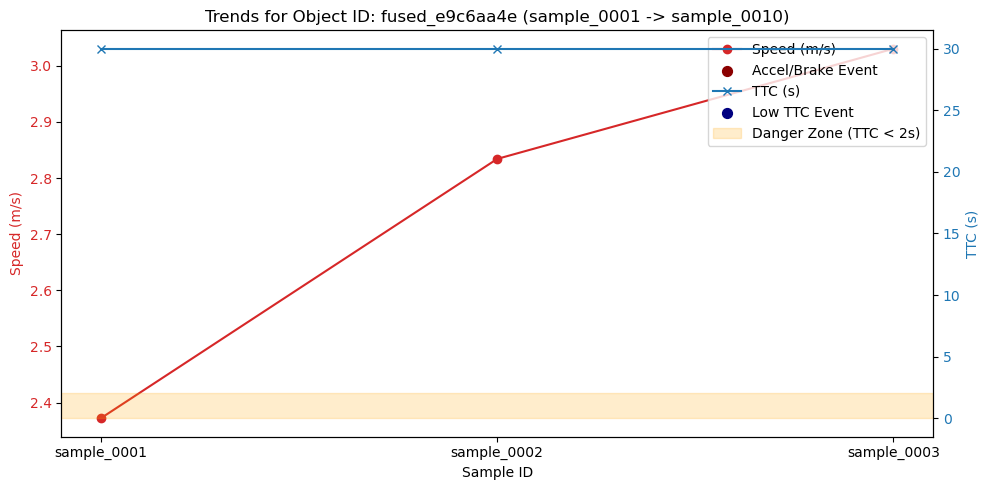

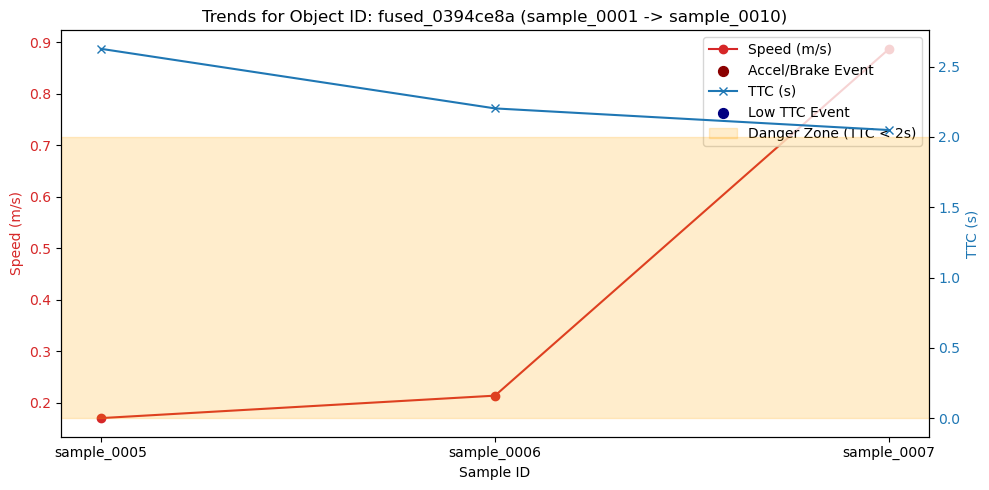

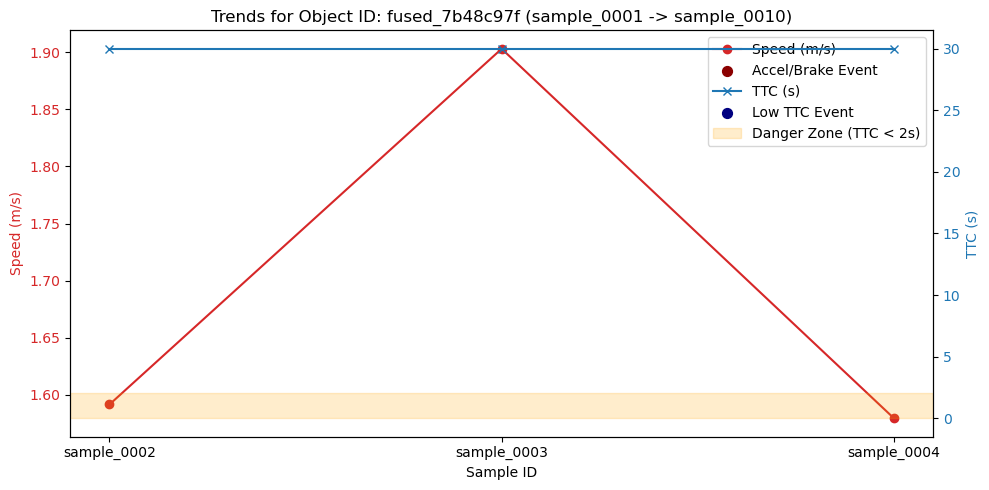

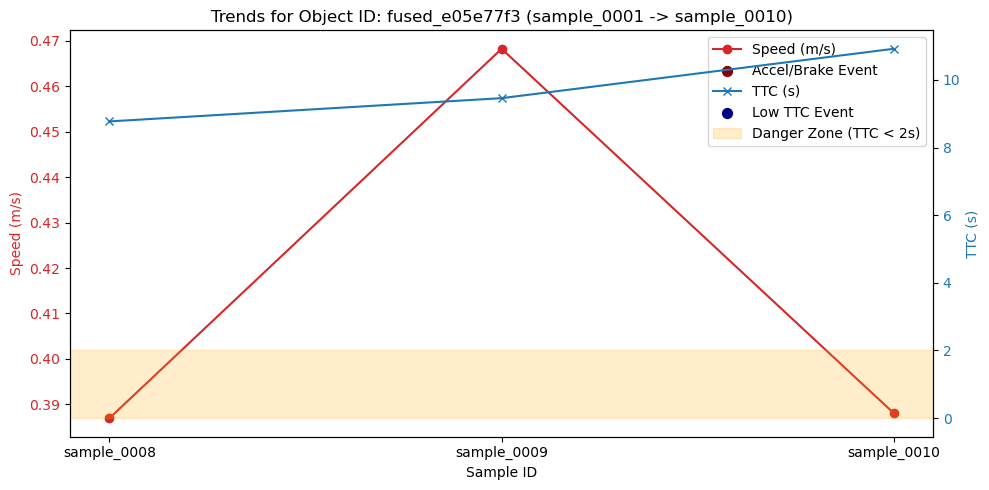

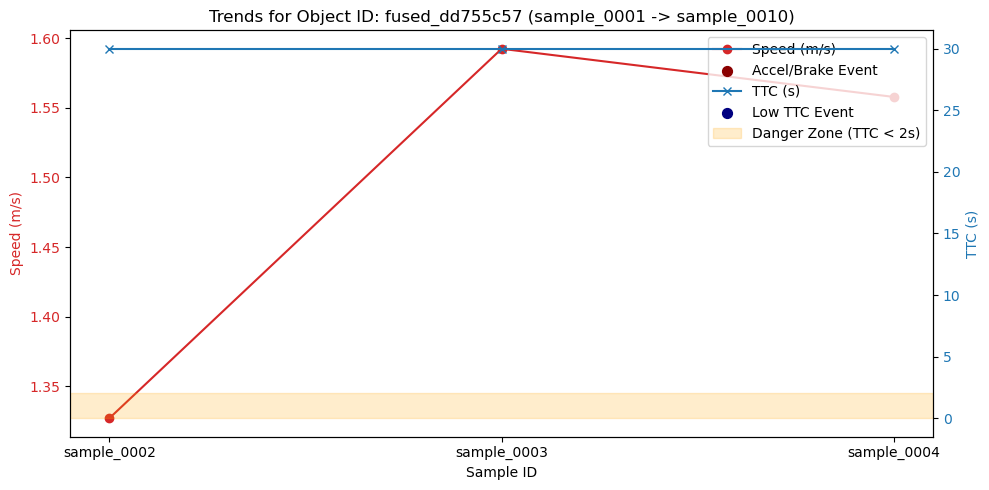

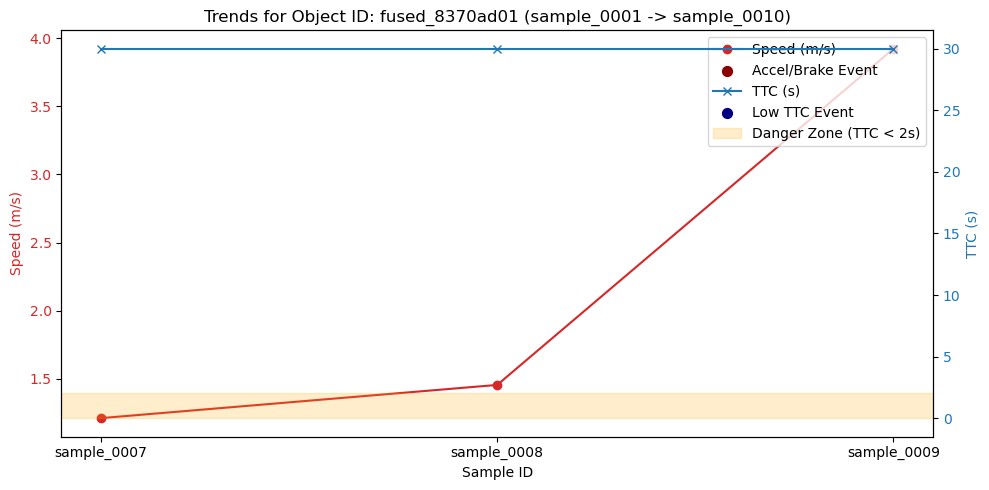

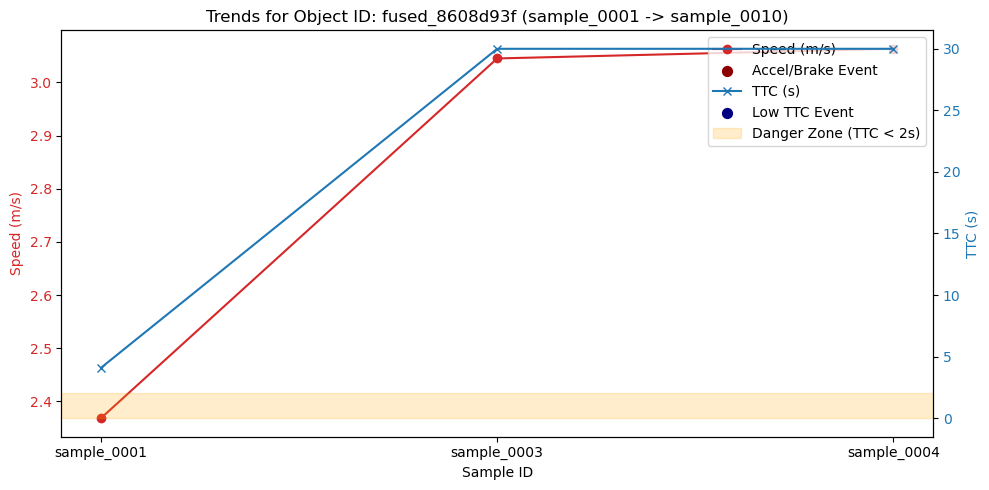

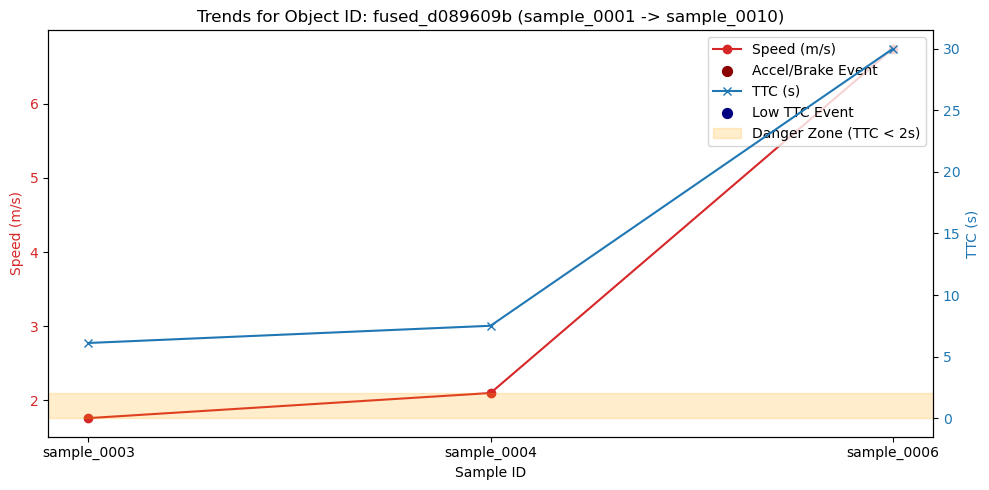

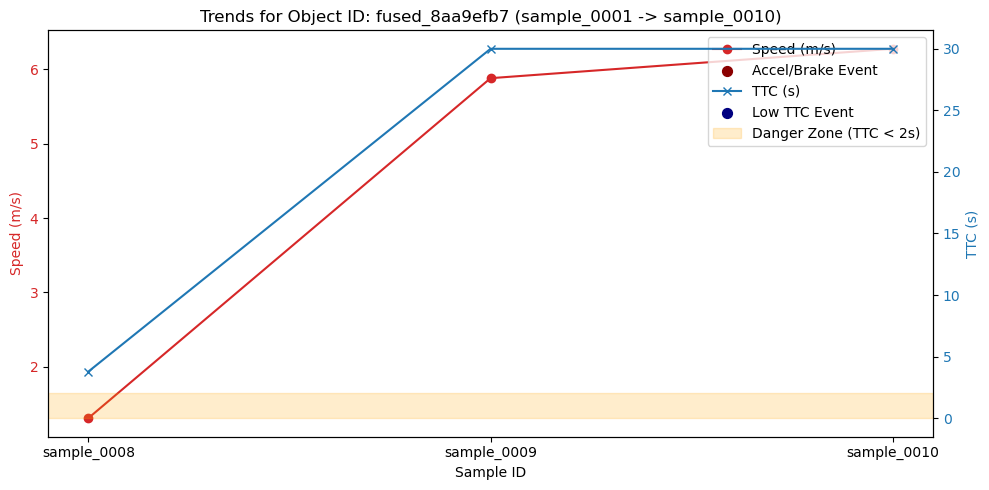

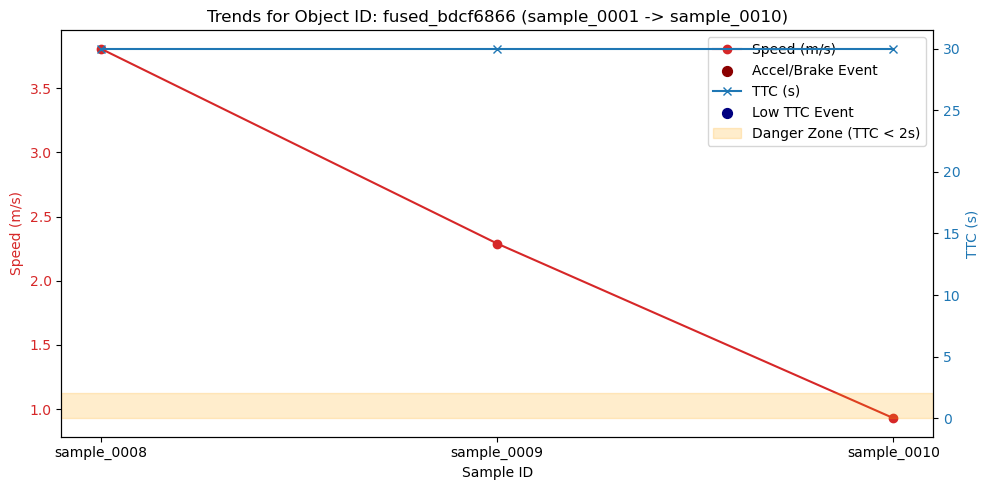

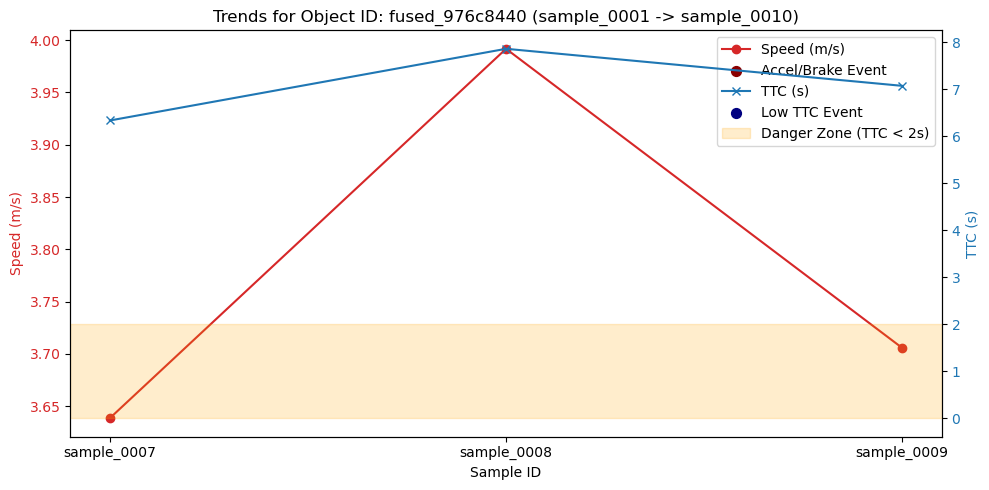

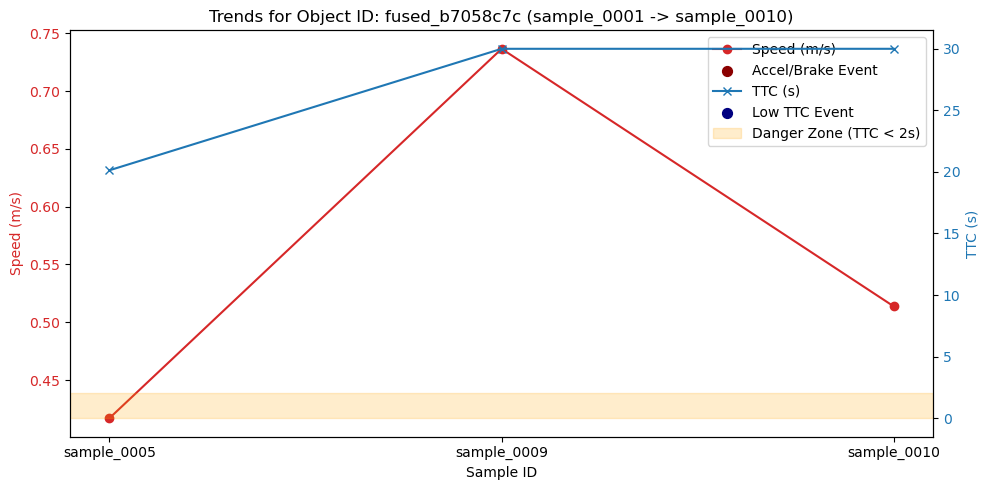

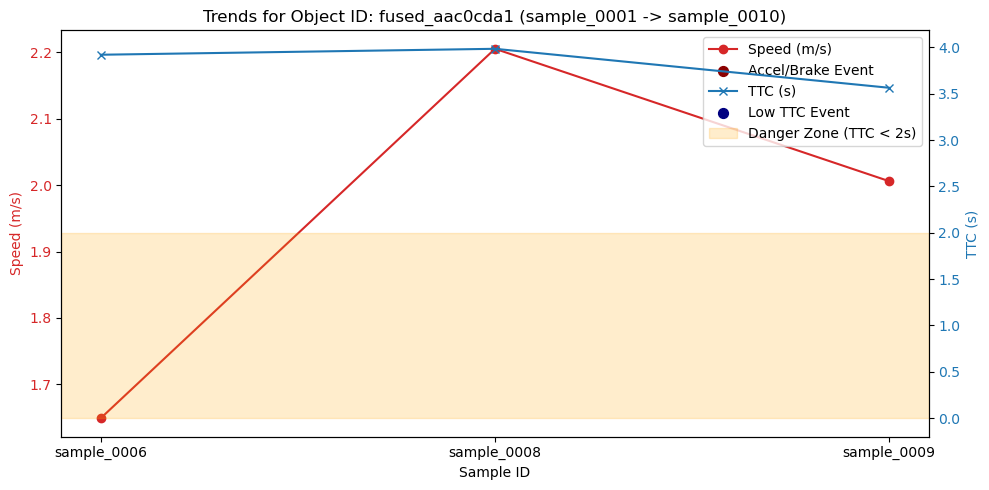

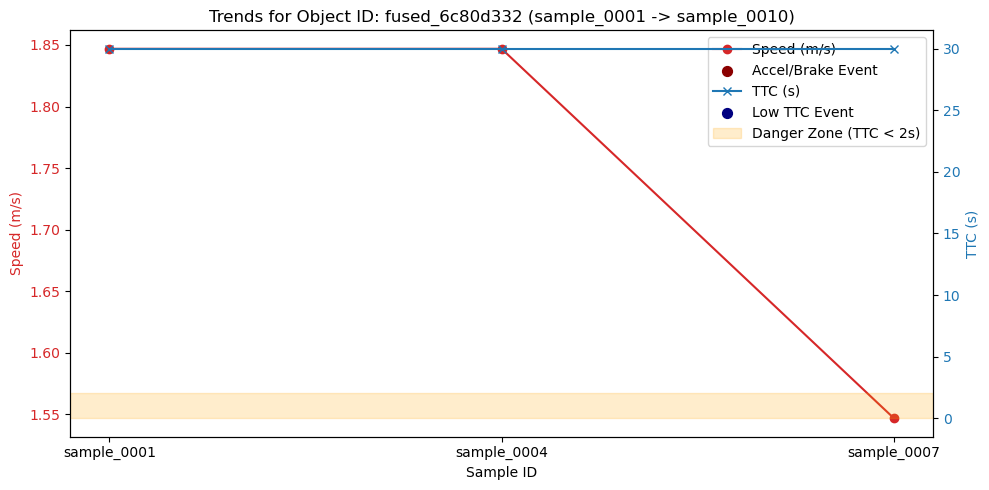

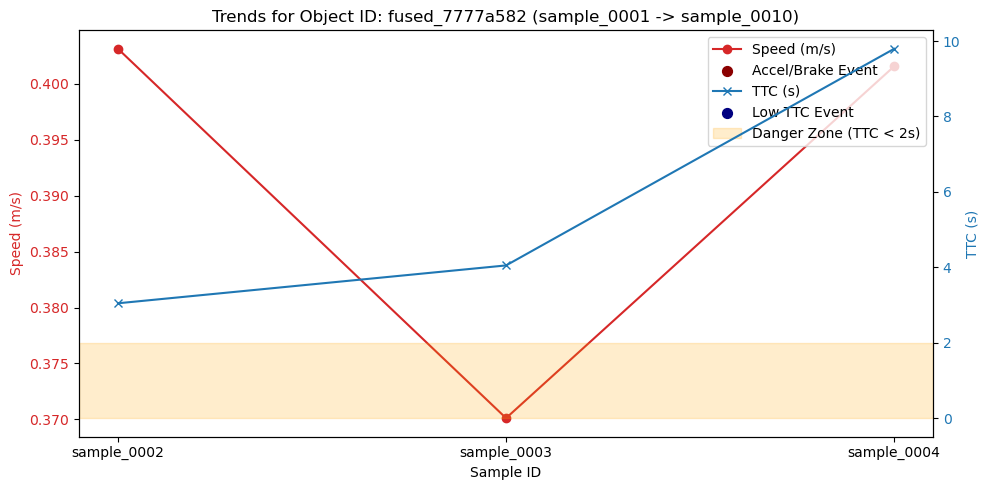

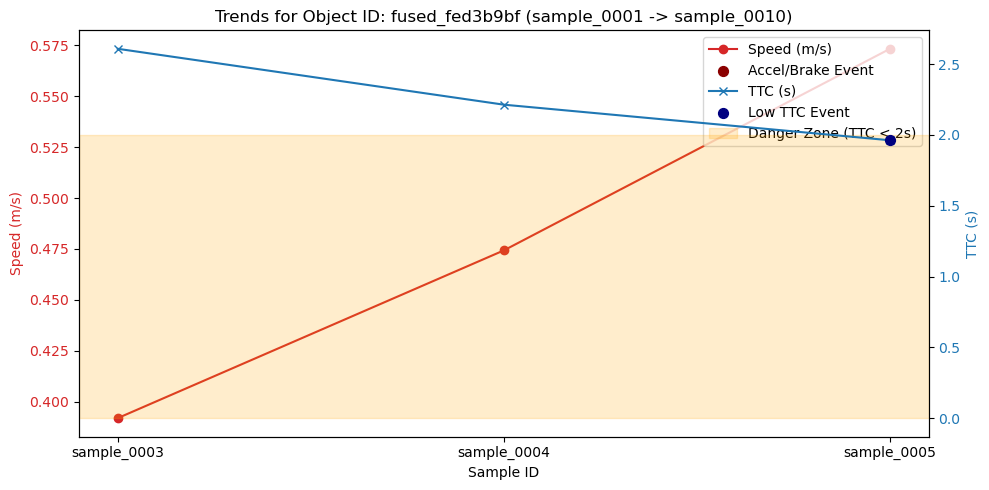

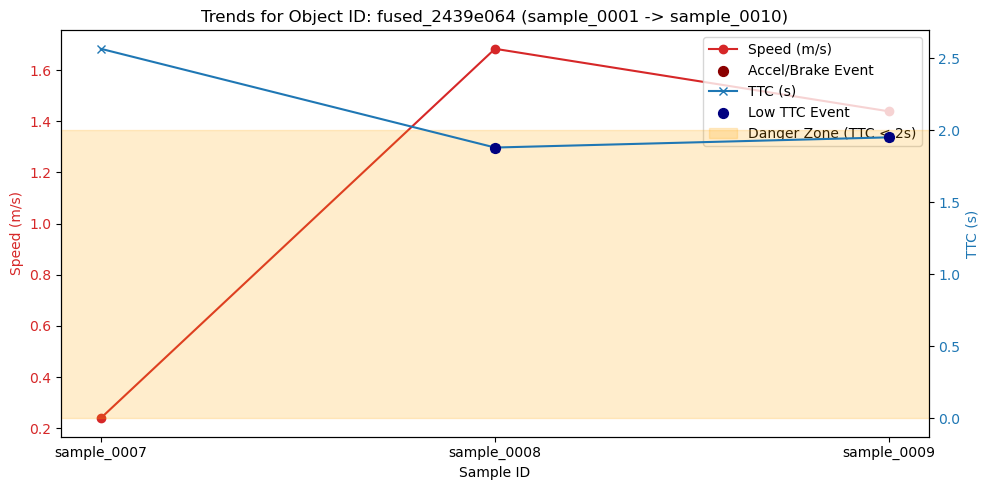

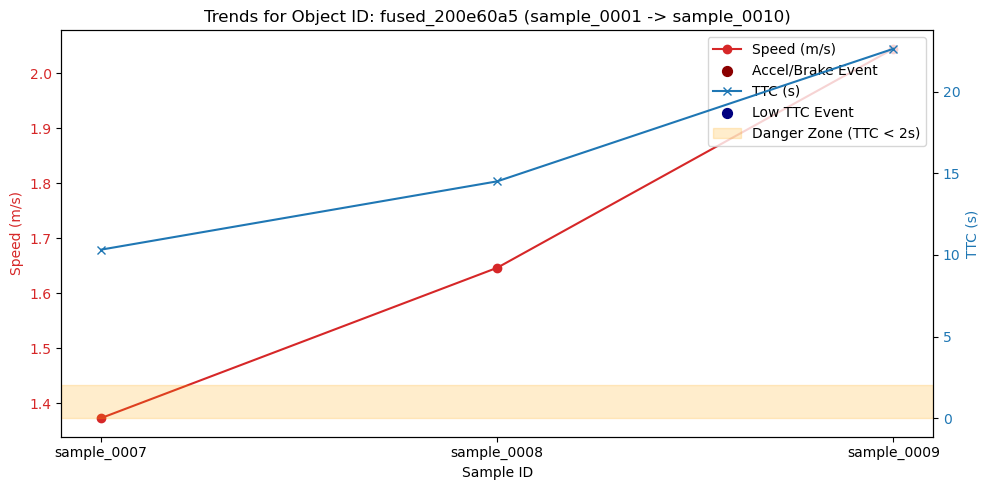

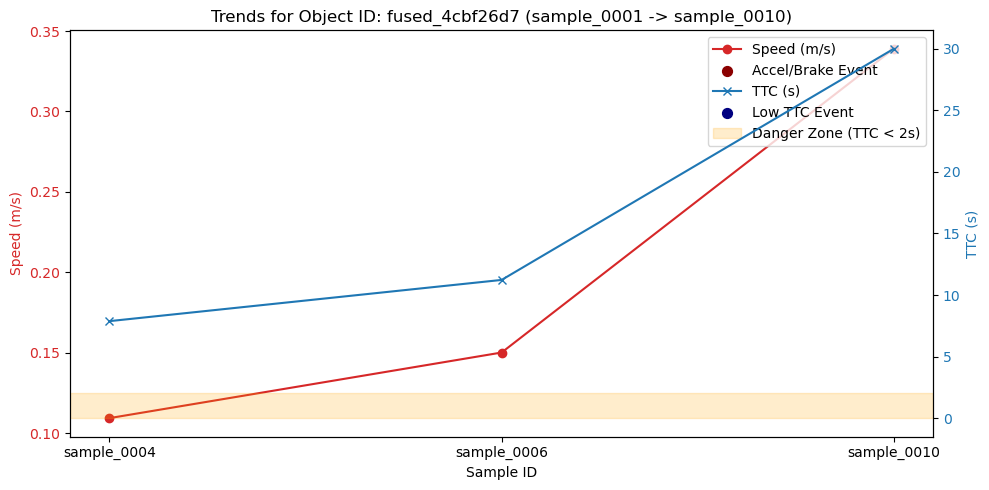

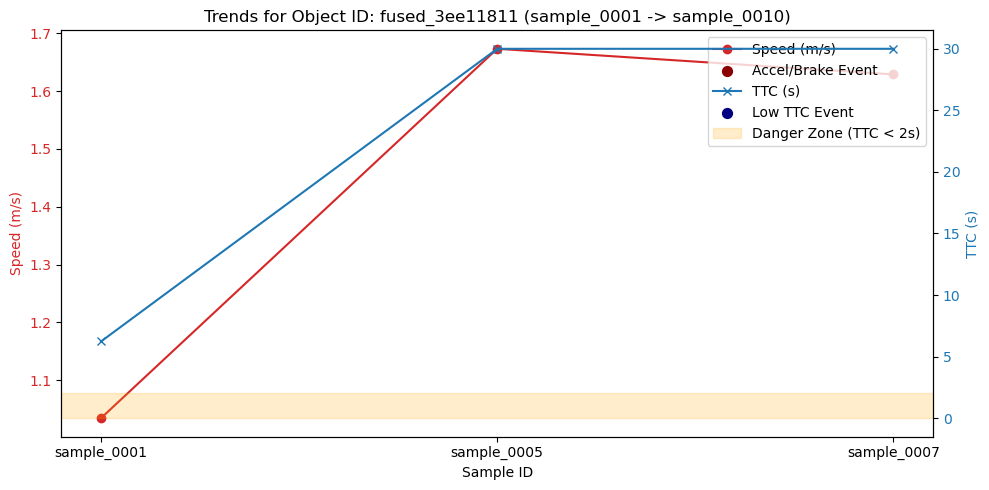

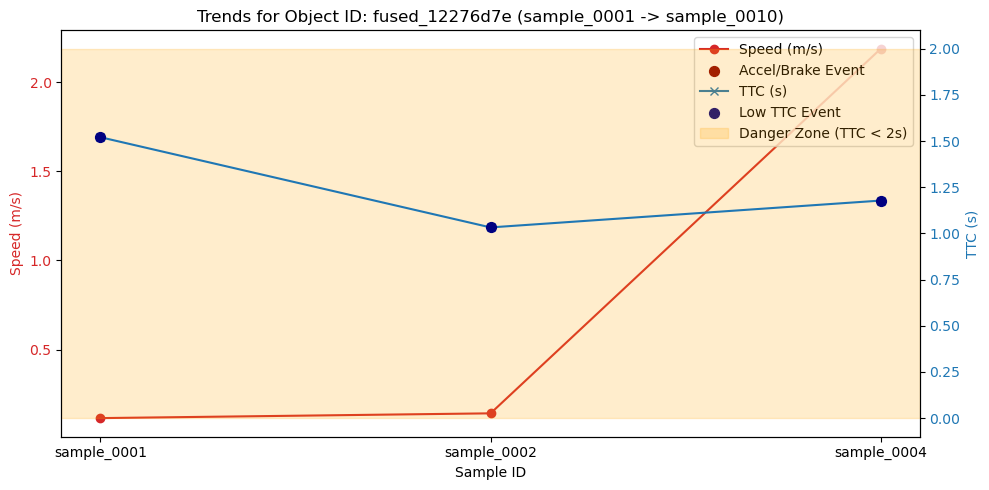

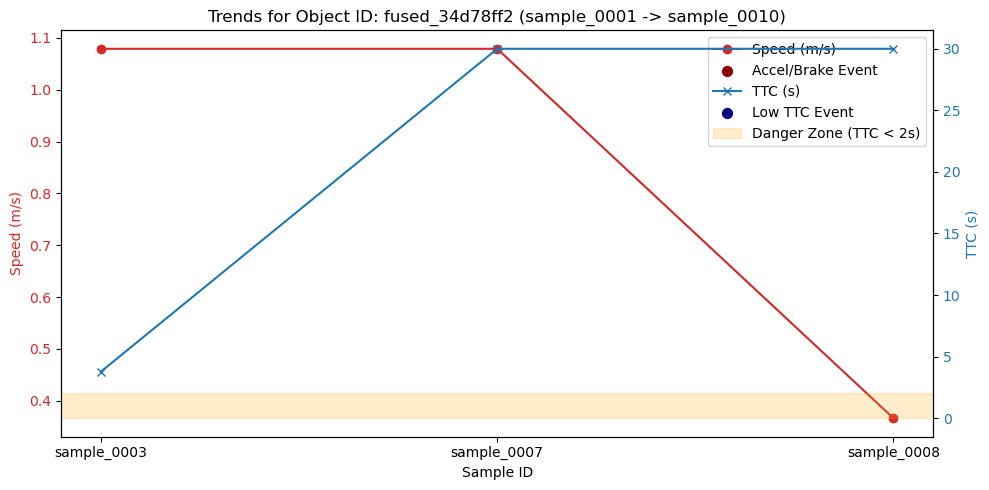

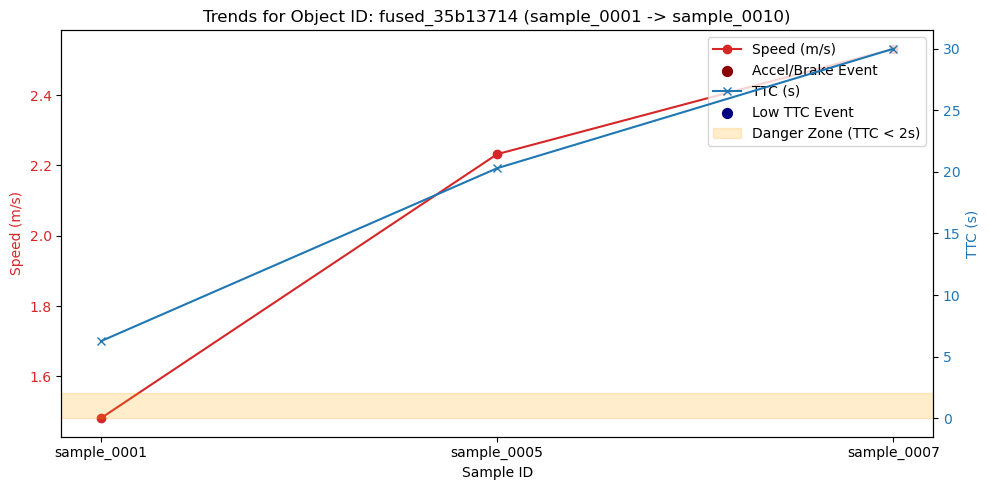

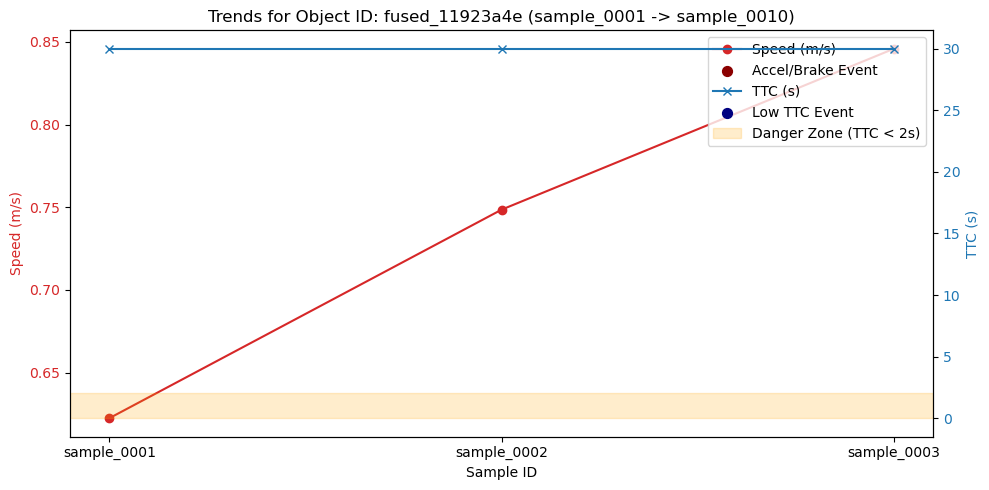

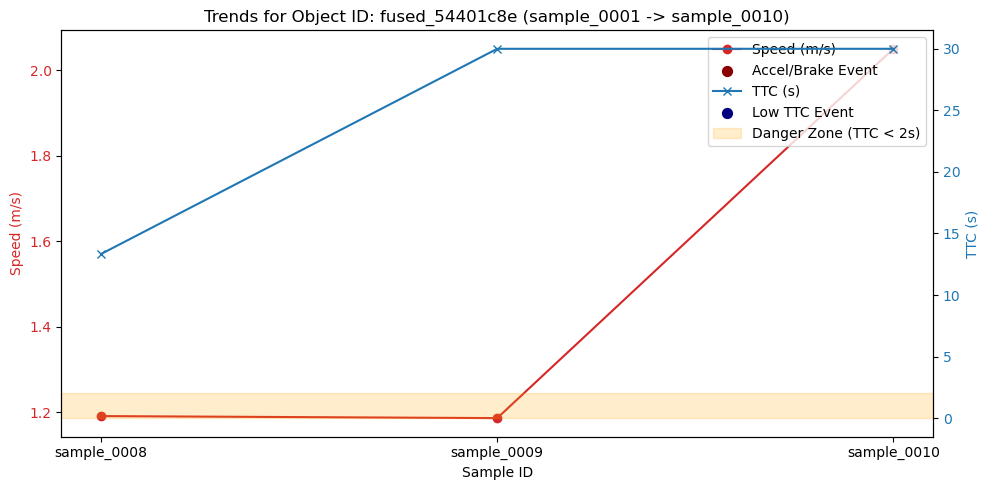

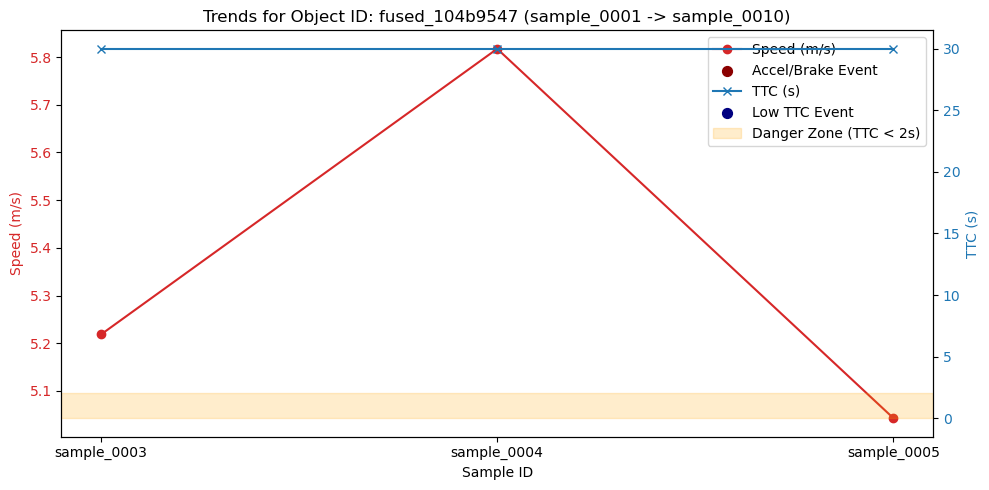

Figures saved to: F:\Sensor fusion Research\output\step_6


In [2]:
# CELL 2 — Speed/TTC trend plots, saved to disk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(STEP5_DIR / "ttc_fused.csv")

# Capped values for readable plotting (inf/extreme values otherwise break the y-axis)
SPEED_CAP = 30.0   # m/s
TTC_CAP   = 30.0   # seconds
df["speed_capped"] = np.hypot(df["vx"], df["vy"]).clip(upper=SPEED_CAP)
df["ttc_capped"] = df["ttc"].replace([np.inf, -np.inf], TTC_CAP).clip(upper=TTC_CAP)

start_sample, end_sample = "sample_0001", "sample_0010"
df_range = df[(df["sample_id"] >= start_sample) & (df["sample_id"] <= end_sample)]

speed_jump_thresh = 5.0
low_ttc_thresh = 2.0

# Only plot objects with at least 3 points in range — avoids flooding output with noise
object_counts = df_range["fused_id"].value_counts()
object_ids = object_counts[object_counts >= 3].index.tolist()
print(f"Plotting {len(object_ids)} objects with 3+ points in {start_sample}..{end_sample}")

for obj_id in object_ids:
    obj_df = df_range[df_range["fused_id"] == obj_id].sort_values("sample_id").copy()
    obj_df["speed_change"] = obj_df["speed_capped"].diff()

    fig, ax1 = plt.subplots(figsize=(10, 5))

    speed_line, = ax1.plot(obj_df["sample_id"], obj_df["speed_capped"],
                            color="tab:red", marker="o", label="Speed (m/s)")
    ax1.set_xlabel("Sample ID")
    ax1.set_ylabel("Speed (m/s)", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    accel_points = obj_df[abs(obj_df["speed_change"]) > speed_jump_thresh]
    accel_scatter = ax1.scatter(accel_points["sample_id"], accel_points["speed_capped"],
                                 color="darkred", s=50, label="Accel/Brake Event", zorder=5)

    ax2 = ax1.twinx()
    ttc_line, = ax2.plot(obj_df["sample_id"], obj_df["ttc_capped"],
                          color="tab:blue", marker="x", label="TTC (s)")
    ax2.set_ylabel("TTC (s)", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    danger_zone = ax2.axhspan(0, low_ttc_thresh, color="orange", alpha=0.2)   # kept as a direct reference

    low_ttc_points = obj_df[obj_df["ttc_capped"] < low_ttc_thresh]
    ttc_scatter = ax2.scatter(low_ttc_points["sample_id"], low_ttc_points["ttc_capped"],
                               color="navy", s=50, label="Low TTC Event", zorder=5)

    lines = [speed_line, accel_scatter, ttc_line, ttc_scatter]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines + [danger_zone], labels + ["Danger Zone (TTC < 2s)"], loc="upper right")

    plt.title(f"Trends for Object ID: {obj_id} ({start_sample} -> {end_sample})")
    fig.tight_layout()

    save_path = STEP6_DIR / f"trend_{obj_id}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

print(f"Figures saved to: {STEP6_DIR}")

## Part B — NEW: Ground-truth evaluation metrics

In [3]:
# CELL 3 — Build ground-truth TTC per instance, using the same compute_ttc logic as Step 5

import json
from collections import defaultdict
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(DATA_ROOT), verbose=False)

with open(STEP0_DIR / "samples_index.json") as f:
    samples_index = json.load(f)

# Ego position/velocity lookup (same construction as Step 5)
ego_pos_by_sample = {}
for sample_id, info in samples_index.items():
    meta_path = STEP1_DIR / "lidar" / sample_id / "lidar_meta.json"
    if not meta_path.exists():
        continue
    with open(meta_path) as f:
        meta = json.load(f)
    ego_pos_by_sample[sample_id] = {
        "pos": np.array(meta["ego_pose"]["translation"][:2]),
        "timestamp": info["timestamp_us"]
    }

sorted_samples = sorted(ego_pos_by_sample.keys(), key=lambda s: ego_pos_by_sample[s]["timestamp"])
ego_vel_by_sample = {}
for i in range(1, len(sorted_samples)):
    s0, s1 = sorted_samples[i-1], sorted_samples[i]
    dt = (ego_pos_by_sample[s1]["timestamp"] - ego_pos_by_sample[s0]["timestamp"]) / 1e6
    if dt > 0:
        ego_vel_by_sample[s1] = (ego_pos_by_sample[s1]["pos"] - ego_pos_by_sample[s0]["pos"]) / dt
if len(sorted_samples) > 1:
    ego_vel_by_sample[sorted_samples[0]] = ego_vel_by_sample.get(sorted_samples[1], np.array([0.0, 0.0]))


# def compute_ttc(px, py, vx, vy, sample_id):
#     if sample_id not in ego_pos_by_sample:
#         return np.nan, np.nan, np.nan
#     ego_pos = ego_pos_by_sample[sample_id]["pos"]
#     ego_vel = ego_vel_by_sample.get(sample_id, np.array([0.0, 0.0]))
#     rel_pos = np.array([px, py]) - ego_pos
#     dist = np.linalg.norm(rel_pos)
#     if dist <= 1e-6:
#         return dist, 0.0, np.inf
#     los = rel_pos / dist
#     rel_vel = np.array([vx, vy]) - ego_vel
#     closing_speed = -np.dot(rel_vel, los)
#     ttc = dist / closing_speed if closing_speed > 1e-6 else np.inf
#     return dist, closing_speed, ttc
MIN_CLOSING_SPEED = 0.3   # m/s — below this, not meaningfully "approaching"
MAX_VALID_TTC = 60.0      # seconds — beyond this, not collision-relevant

def compute_ttc(px, py, vx, vy, sample_id):
    if sample_id not in ego_pos_by_sample:
        return np.nan, np.nan, np.nan
    ego_pos = ego_pos_by_sample[sample_id]["pos"]
    ego_vel = ego_vel_by_sample.get(sample_id, np.array([0.0, 0.0]))

    rel_pos = np.array([px, py]) - ego_pos
    dist = np.linalg.norm(rel_pos)
    if dist <= 1e-6:
        return dist, 0.0, np.inf

    los = rel_pos / dist
    rel_vel = np.array([vx, vy]) - ego_vel
    closing_speed = -np.dot(rel_vel, los)

    if closing_speed < MIN_CLOSING_SPEED:
        return dist, closing_speed, np.inf        # not meaningfully approaching

    ttc = dist / closing_speed
    if ttc > MAX_VALID_TTC:
        return dist, closing_speed, np.inf          # too far out to be meaningful

    return dist, closing_speed, ttc


# Ground-truth annotation positions per sample
gt_by_sample = defaultdict(list)
for sample_id, info in samples_index.items():
    sample = nusc.get('sample', info['sample_token'])
    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        gt_by_sample[sample_id].append({
            "instance_token": ann['instance_token'],
            "pos": np.array(ann['translation'][:2])
        })

# Build per-instance trajectories, compute true TTC from real position deltas
traj_by_instance = defaultdict(list)
for sample_id, dets in gt_by_sample.items():
    ts = samples_index[sample_id]["timestamp_us"]
    for d in dets:
        traj_by_instance[d["instance_token"]].append((sample_id, ts, d["pos"]))

gt_ttc_lookup = {}   # (sample_id, instance_token) -> {"ttc":, "pos":}
for inst, points in traj_by_instance.items():
    points = sorted(points, key=lambda p: p[1])
    for i in range(1, len(points)):
        s0, t0, p0 = points[i-1]
        s1, t1, p1 = points[i]
        dt = (t1 - t0) / 1e6
        if dt <= 0:
            continue
        v = (p1 - p0) / dt
        dist, cs, ttc = compute_ttc(p1[0], p1[1], v[0], v[1], s1)
        gt_ttc_lookup[(s1, inst)] = {"ttc": ttc, "pos": p1}

print(f"Ground-truth TTC computed for {len(gt_ttc_lookup)} (sample, instance) pairs "
      f"across {len(traj_by_instance)} unique real-world objects.")

Ground-truth TTC computed for 17627 (sample, instance) pairs across 911 unique real-world objects.


In [4]:
# CELL 4 — Match each predicted track to ONE locked ground-truth identity, not per-frame nearest

MATCH_DIST_THRESHOLD = 3.0   # metres — max distance to lock a track to a GT instance at its first frame
GOOD_ERROR_THRESHOLD = 1.0   # seconds — |pred_ttc - gt_ttc| below this counts as "Good"


def match_predictions_to_ground_truth(pred_df):
    pairs = []

    for fid, track in pred_df.groupby("fused_id"):
        track = track.sort_values("sample_id").reset_index(drop=True)
        locked_instance = None

        for _, row in track.iterrows():
            sample_id = row["sample_id"]
            pred_pos = np.array([row["x"], row["y"]])

            if locked_instance is None:
                # First frame only — find and LOCK the nearest GT instance
                gt_entries = [(inst, v) for (s, inst), v in gt_ttc_lookup.items() if s == sample_id]
                if not gt_entries:
                    continue
                gt_positions = np.array([v["pos"] for _, v in gt_entries])
                dists = np.linalg.norm(gt_positions - pred_pos, axis=1)
                min_idx = np.argmin(dists)
                if dists[min_idx] < MATCH_DIST_THRESHOLD:
                    locked_instance = gt_entries[min_idx][0]
                else:
                    continue   # no GT close enough at first frame — this track stays unmatched

            # Every frame (including the locking one) uses the SAME locked identity
            key = (sample_id, locked_instance)
            if key in gt_ttc_lookup:
                pairs.append({
                    "fused_id": fid, "sample_id": sample_id,
                    "instance_token": locked_instance,
                    "pred_ttc": row["ttc"], "gt_ttc": gt_ttc_lookup[key]["ttc"]
                })
            # else: locked GT has no annotation this frame — skip, don't fall back to nearest

    return pd.DataFrame(pairs)


print("match_predictions_to_ground_truth() defined — identity locked once per track.")

match_predictions_to_ground_truth() defined — identity locked once per track.


In [5]:
# CELL 5 - Compute the full evaluation table for all 4 datasets

def compute_evaluation_metrics(sensor_name, pred_df):
    valid_pred = pred_df[np.isfinite(pred_df["ttc"])]
    percent_valid = len(valid_pred) / len(pred_df) * 100 if len(pred_df) > 0 else 0.0

    pairs_df = match_predictions_to_ground_truth(pred_df)
    n_tracks_total = pred_df["fused_id"].nunique()
    n_tracks_matched = pairs_df["fused_id"].nunique() if len(pairs_df) > 0 else 0
    # FIXED: match_predictions_to_ground_truth() retries the lock attempt on
    # EVERY frame until one succeeds (or the track ends), not only the first
    # frame -- the old message said "at their first frame", which overstated
    # how strict the matching is.
    print(f"  {sensor_name}: {n_tracks_matched}/{n_tracks_total} tracks found a GT lock (checked every frame of the track until one succeeded)")
    valid_pairs = pairs_df[np.isfinite(pairs_df["pred_ttc"]) & np.isfinite(pairs_df["gt_ttc"])] if len(pairs_df) > 0 else pairs_df

    if len(valid_pairs) > 0:
        errors = (valid_pairs["pred_ttc"] - valid_pairs["gt_ttc"]).abs()
        mae = errors.mean()
        rmse = np.sqrt((errors ** 2).mean())
        good_pct = (errors < GOOD_ERROR_THRESHOLD).mean() * 100
    else:
        mae = rmse = good_pct = np.nan

    stability = pred_df.groupby("fused_id")["ttc"].apply(
        lambda s: s[np.isfinite(s)].std() if np.isfinite(s).sum() > 1 else np.nan
    ).mean()

    return {
        "Sensor": sensor_name,
        "Good_pct": round(good_pct, 2) if pd.notna(good_pct) else None,
        "Bad_pct": round(100 - good_pct, 2) if pd.notna(good_pct) else None,
        "Mean_TTC": round(valid_pred["ttc"].mean(), 2) if len(valid_pred) > 0 else None,
        "Median_TTC": round(valid_pred["ttc"].median(), 2) if len(valid_pred) > 0 else None,
        "Percent_Valid": round(percent_valid, 2),
        "Stability": round(stability, 2) if pd.notna(stability) else None,
        "MAE": round(mae, 2) if pd.notna(mae) else None,
        "RMSE": round(rmse, 2) if pd.notna(rmse) else None,
        # FIXED: these were computed and printed above but never made it into
        # the returned dict, so they never reached evaluation_metrics.csv --
        # "how many of this sensor's tracks were even comparable to ground
        # truth at all" was missing from the final table.
        "N_Tracks_Total": int(n_tracks_total),
        "N_Tracks_GT_Matched": int(n_tracks_matched),
        "n_matched_pairs": len(valid_pairs)
    }


all_metrics = []
for name in ["lidar", "radar", "camera", "camera_mono", "fused"]:
    pred_df = pd.read_csv(STEP5_DIR / f"ttc_{name}.csv")
    print(f"Evaluating {name}...")
    all_metrics.append(compute_evaluation_metrics(name, pred_df))

metrics_df = pd.DataFrame(all_metrics)

# Sanity check: two sensors reporting a suspiciously identical n_matched_pairs
# usually means a copy-paste bug (e.g. accidentally reusing one sensor's
# pred_df for another) rather than a real coincidence -- flag it instead of
# silently trusting the numbers.
dup_counts = metrics_df["n_matched_pairs"][metrics_df["n_matched_pairs"] > 0]
dup_counts = dup_counts[dup_counts.duplicated(keep=False)]
if len(dup_counts) > 0:
    dup_sensors = metrics_df.loc[dup_counts.index, "Sensor"].tolist()
    print(f"\u26a0\ufe0f  WARNING: sensors {dup_sensors} report the exact same n_matched_pairs "
          f"({sorted(dup_counts.unique())}) -- verify this isn't a copy-paste bug before trusting it.")

metrics_path = STEP6_DIR / "evaluation_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"\nSaved: {metrics_path}")
display(metrics_df)

Evaluating lidar...


  lidar: 1051/2838 tracks found a GT lock (checked every frame of the track until one succeeded)


Evaluating radar...


  radar: 697/1693 tracks found a GT lock (checked every frame of the track until one succeeded)
Evaluating camera...


  camera: 1030/1131 tracks found a GT lock (checked every frame of the track until one succeeded)
Evaluating camera_mono...


  camera_mono: 790/953 tracks found a GT lock (checked every frame of the track until one succeeded)
Evaluating fused...


  fused: 1487/3876 tracks found a GT lock (checked every frame of the track until one succeeded)



Saved: F:\Sensor fusion Research\output\step_6\evaluation_metrics.csv


,Sensor,Good_pct,Bad_pct,Mean_TTC,Median_TTC,Percent_Valid,Stability,MAE,RMSE,N_Tracks_Total,N_Tracks_GT_Matched,n_matched_pairs
0,lidar,50.22,49.78,10.45,5.40,41.02,4.03,3.54,7.41,2838,1051,2027
1,radar,34.51,65.49,11.41,7.23,40.04,3.36,5.53,10.06,1693,697,678
2,camera,52.85,47.15,8.57,5.30,52.56,2.64,2.86,5.87,1131,1030,1792
3,camera_mono,42.16,57.84,8.20,5.01,54.77,2.98,3.75,7.07,953,790,1658
4,fused,49.57,50.43,11.20,6.40,41.36,4.00,3.82,8.11,3876,1487,2459


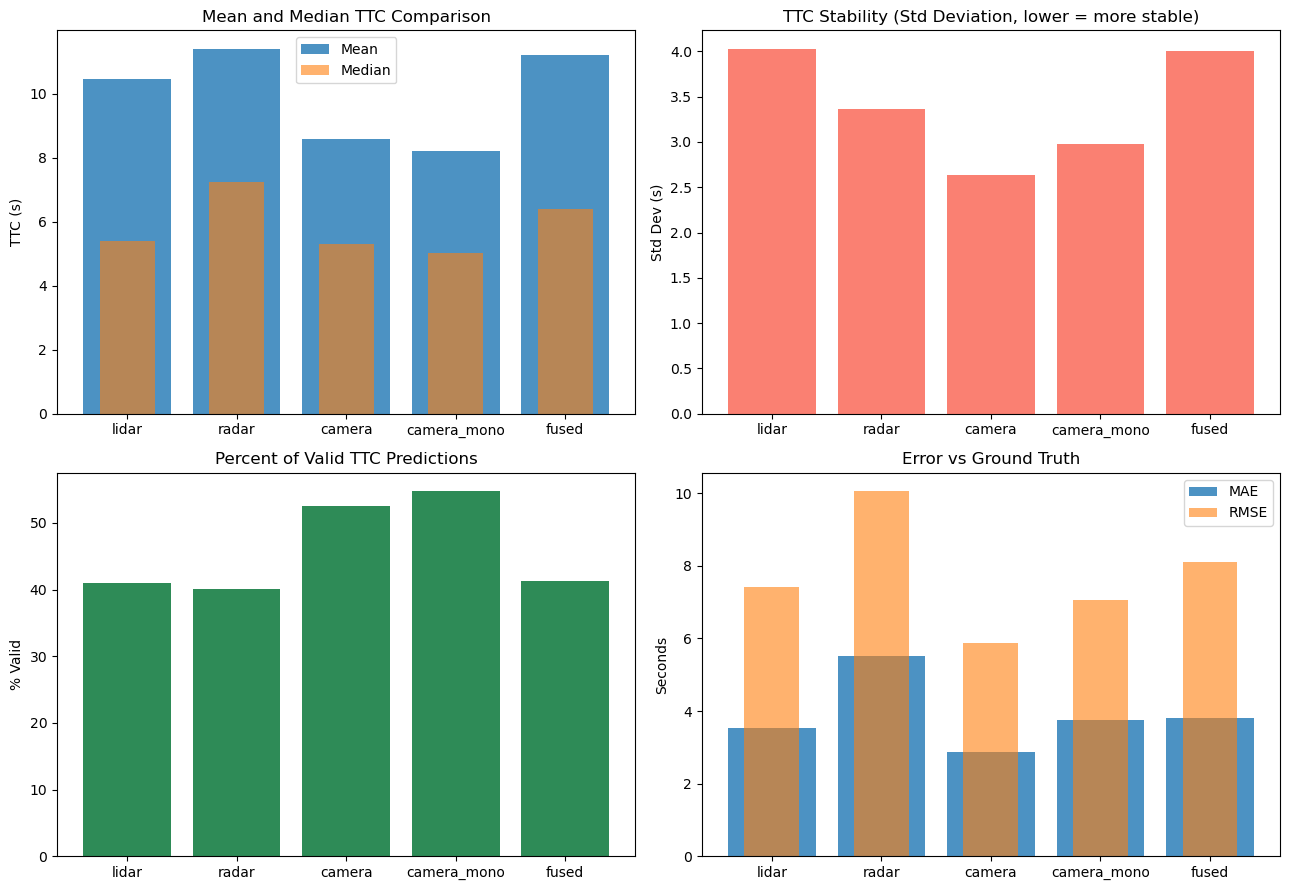

Saved: F:\Sensor fusion Research\output\step_6\evaluation_charts.png


In [6]:
# CELL 6 — Comparison charts (matches dissertation Figure 19 layout)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].bar(metrics_df["Sensor"], metrics_df["Mean_TTC"], label="Mean", alpha=0.8)
axes[0, 0].bar(metrics_df["Sensor"], metrics_df["Median_TTC"], label="Median", alpha=0.6, width=0.5)
axes[0, 0].set_title("Mean and Median TTC Comparison")
axes[0, 0].set_ylabel("TTC (s)"); axes[0, 0].legend()

axes[0, 1].bar(metrics_df["Sensor"], metrics_df["Stability"], color="salmon")
axes[0, 1].set_title("TTC Stability (Std Deviation, lower = more stable)")
axes[0, 1].set_ylabel("Std Dev (s)")

axes[1, 0].bar(metrics_df["Sensor"], metrics_df["Percent_Valid"], color="seagreen")
axes[1, 0].set_title("Percent of Valid TTC Predictions")
axes[1, 0].set_ylabel("% Valid")

axes[1, 1].bar(metrics_df["Sensor"], metrics_df["MAE"], label="MAE", alpha=0.8)
axes[1, 1].bar(metrics_df["Sensor"], metrics_df["RMSE"], label="RMSE", alpha=0.6, width=0.5)
axes[1, 1].set_title("Error vs Ground Truth")
axes[1, 1].set_ylabel("Seconds"); axes[1, 1].legend()

plt.tight_layout()
chart_path = STEP6_DIR / "evaluation_charts.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

In [7]:
# CELL 7 (NEW) — Diagnostic: does fusion's error come from bad within-frame merges?
# Compares MAE for fused points that combined 2+ sensors vs points passed through from just 1 sensor

from config import STEP4_DIR

# Reload Step 4's raw fused output — it still has the "sensors" column
# (Step 5's CSV dropped it when loading, so we go back to the source)
raw_fused_df = pd.read_csv(STEP4_DIR / "fused_tracks_all.csv")[["fused_id", "sample_id", "sensors"]]

# Get GT-matched pairs for the fused dataset specifically
fused_pred_df = pd.read_csv(STEP5_DIR / "ttc_fused.csv")
fused_pairs_df = match_predictions_to_ground_truth(fused_pred_df)

# Join sensor contribution info onto the matched pairs
fused_pairs_df = fused_pairs_df.merge(raw_fused_df, on=["fused_id", "sample_id"], how="left")

# Split into multi-sensor-merged vs single-sensor-passthrough
is_merged = fused_pairs_df["sensors"].str.contains(r"\+", na=False)
merged_group = fused_pairs_df[is_merged]
single_group = fused_pairs_df[~is_merged]


def group_error_stats(name, group):
    valid = group[np.isfinite(group["pred_ttc"]) & np.isfinite(group["gt_ttc"])]
    if len(valid) == 0:
        print(f"{name}: no valid pairs")
        return
    errors = (valid["pred_ttc"] - valid["gt_ttc"]).abs()
    mae = errors.mean()
    rmse = np.sqrt((errors ** 2).mean())
    print(f"{name}: n={len(valid)}, MAE={mae:.2f}, RMSE={rmse:.2f}")


print("Fusion error breakdown by merge status:\n")
group_error_stats("Multi-sensor merged (2+ sensors combined)", merged_group)
group_error_stats("Single-sensor passthrough (1 sensor only)", single_group)

print(f"\nTotal matched fused pairs: {len(fused_pairs_df)}")
print(f"  Multi-sensor merged      : {len(merged_group)} ({len(merged_group)/len(fused_pairs_df)*100:.1f}%)")
print(f"  Single-sensor passthrough: {len(single_group)} ({len(single_group)/len(fused_pairs_df)*100:.1f}%)")

Fusion error breakdown by merge status:

Multi-sensor merged (2+ sensors combined): n=860, MAE=2.90, RMSE=6.17
Single-sensor passthrough (1 sensor only): n=1599, MAE=4.32, RMSE=8.98

Total matched fused pairs: 7139
  Multi-sensor merged      : 2115 (29.6%)
  Single-sensor passthrough: 5024 (70.4%)
